# Drug-Likeness Assessment Pipeline v2 (Integrated)

**Purpose:** Evaluate drug-likeness of generated and existing candidate molecules using:
1. **Real experimental labels** (ClinTox FDA approval, Tox21 multi-assay toxicity) — not self-derived rules
2. **Pre-trained GNN models** from the Optim pipeline (loaded from `model_o/` weights)
3. **Morgan fingerprints (ECFP4)** as structural features — not the same descriptors used to define labels
4. **Multi-task toxicity prediction** on 12 Tox21 assay endpoints
5. **ADMET profiling** — Absorption, Distribution, Metabolism, Excretion descriptors
6. **Structural alert filtering** — PAINS and Brenk with hardened multiplicative penalties
7. **Multi-objective Pareto optimization** — efficacy vs safety vs synthesizability trade-offs
8. **Target-specific docking integration** — docking scores from 5 protein targets
9. **Chemical diversity analysis** — UMAP clustering, Tanimoto diversity, Murcko scaffold decomposition
10. **Final candidate selection** — scaffold-diverse, all-filters-passed shortlist with 3D conformers

### Pipeline Flow
```
Optim (model_o/) → Pre-trained GNN/EGNN weights
                 → Generated candidates (489 molecules)
                 → Existing candidates (106 molecules, 5 targets)
                           ↓
Drug-Likeness v2 → ClinTox training (FDA/CT_TOX)
                 → Tox21 training (12 endpoints)
                 → Score all candidates through ALL models
                 → Apply hardened penalties (Brenk ×0.5, PAINS ×0.7)
                 → ADMET profiling + scaffold analysis
                 → Pareto front + diversity analysis
                 → Final filtered shortlist + 3D SDF export
```

In [ ]:
!apt-get install -y unrar

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 37 not upgraded.


In [ ]:
!unrar x "project.rar" "/content/"


UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from project.rar

Extracting  /content/Ki_bind.tsv                                           0%  1%  2%  3%  OK 
Extracting  /content/master_drug_discovery_final.csv                       3%  4%  5%  6%  7%  8%  9% 10% 11% 12% 13% 14% 15% 16% 17% 18% 19% 20% 21% 22% 23% 24% 25% 26% 27% 28% 29% 30% 31% 32% 33% 34% 35% 36% 37% 38% 39% 40% 41% 42% 43%  OK 
Extracting  /content/tox21_cleaned.csv                                    43%  OK 
Creating    /content/model_o                                          OK
Extracting  /content/model_o/best_egnn_model.pt                           43% 44% 45% 46%  OK 
Extracting  /content/model_o/best_smiles_decoder.pt                       46% 

In [ ]:
# ─── Cell 1: Install Dependencies ───
# Uncomment if running on Colab or fresh environment
!pip install rdkit torch torchvision torchaudio
!pip install torch-scatter torch-sparse torch-cluster torch-spline-conv torch-geometric -f https://data.pyg.org/whl/torch-2.2.0+cpu.html
!pip install xgboost lightgbm shap imbalanced-learn
!pip install umap-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 62.9 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.2.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 511.5/511.5 kB 13.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 56.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 774.1/774.1 kB 51.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.4/215.4 kB 21.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 29.9 MB/s eta 0:00:00


In [ ]:
# ─── Cell 2: Imports & Configuration ───
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import sklearn.base
warnings.filterwarnings('ignore')

# RDKit
from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem, QED, RDConfig
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit import DataStructs

# ML
import torch
import torch.nn as nn
import torch.nn.functional as F

# Sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb
import shap
from tqdm.auto import tqdm
from scipy import stats
from scipy.spatial.distance import pdist, squareform
import umap

# PyG
from torch_geometric.data import Data, Batch
from torch_geometric.nn import (
    GATv2Conv, global_mean_pool, global_add_pool, GraphNorm
)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print(f'Device: {DEVICE}')
print(f'PyTorch: {torch.__version__}')
print('Imports OK.')

Device: cuda
PyTorch: 2.10.0+cu128
Imports OK.


In [ ]:
# ─── Cell 3: Configure Paths ───
# Adjust BASE to your data directory
BASE = '/content/'
MODEL_DIR = '/content/model_o/'

# Load datasets
clintox      = pd.read_csv(f'{BASE}clintox.csv')
tox21        = pd.read_csv(f'{BASE}tox21_cleaned.csv')
drug_cleaned = pd.read_csv(f'{BASE}drug_cleaned.csv')
drug_protein = pd.read_csv(f'{BASE}drug_protein_diagnosis.csv')
generated    = pd.read_csv(f'{MODEL_DIR}generated_candidates.csv')
existing     = pd.read_csv(f'{MODEL_DIR}existing_candidates_ranked.csv')

print('=== Datasets Loaded ===')
for name, df in [('clintox', clintox), ('tox21', tox21),
                 ('drug_cleaned', drug_cleaned), ('drug_protein', drug_protein),
                 ('generated', generated), ('existing', existing)]:
    print(f'  {name:20s} {df.shape[0]:>8,} rows  {df.shape[1]:>3} cols')

print(f'\nClinTox columns: {list(clintox.columns)}')
print(f'Tox21 columns:   {list(tox21.columns)}')

=== Datasets Loaded ===
  clintox                 1,484 rows    3 cols
  tox21                   7,831 rows   16 cols
  drug_cleaned           76,543 rows   16 cols
  drug_protein               99 rows    7 cols
  generated                 489 rows   16 cols
  existing                  106 rows   18 cols

ClinTox columns: ['smiles', 'FDA_APPROVED', 'CT_TOX']
Tox21 columns:   ['molecule_id', 'drug_smiles', 'androgen_receptor', 'androgen_receptor_lbd', 'aryl_hydrocarbon_receptor', 'aromatase', 'estrogen_receptor', 'estrogen_receptor_lbd', 'ppar_gamma', 'antioxidant_response', 'dna_damage', 'heat_shock', 'mitochondrial_membrane', 'tumor_suppressor_p53', 'toxicity_score', 'is_toxic']


## Part 1: Model Architecture Definitions

Reproduce the exact architectures from the Optim pipeline so we can load the pre-trained weights.

In [ ]:
# ─── Cell 4: Atom/Bond Feature Engineering (must match training) ───

ATOM_FEATURES = {
    'atomic_num': list(range(1, 119)),
    'degree': [0, 1, 2, 3, 4, 5],
    'formal_charge': [-2, -1, 0, 1, 2],
    'hybridization': [
        Chem.rdchem.HybridizationType.SP,
        Chem.rdchem.HybridizationType.SP2,
        Chem.rdchem.HybridizationType.SP3,
        Chem.rdchem.HybridizationType.SP3D,
        Chem.rdchem.HybridizationType.SP3D2
    ],
    'num_hs': [0, 1, 2, 3, 4],
}

def one_hot_encode(value, choices):
    encoding = [0] * (len(choices) + 1)
    if value in choices:
        encoding[choices.index(value)] = 1
    else:
        encoding[-1] = 1
    return encoding

def get_atom_features(atom):
    features = []
    features += one_hot_encode(atom.GetAtomicNum(), ATOM_FEATURES['atomic_num'])
    features += one_hot_encode(atom.GetDegree(), ATOM_FEATURES['degree'])
    features += one_hot_encode(atom.GetFormalCharge(), ATOM_FEATURES['formal_charge'])
    features += one_hot_encode(atom.GetHybridization(), ATOM_FEATURES['hybridization'])
    features += one_hot_encode(atom.GetTotalNumHs(), ATOM_FEATURES['num_hs'])
    features.append(1 if atom.GetIsAromatic() else 0)
    features.append(atom.GetMass() / 100.0)
    return features

def get_bond_features(bond):
    bt = bond.GetBondType()
    features = [
        bt == Chem.rdchem.BondType.SINGLE,
        bt == Chem.rdchem.BondType.DOUBLE,
        bt == Chem.rdchem.BondType.TRIPLE,
        bt == Chem.rdchem.BondType.AROMATIC,
        bond.GetIsConjugated(),
        bond.IsInRing()
    ]
    return [int(f) for f in features]

def smiles_to_graph(smiles, y=None):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    atom_feats = [get_atom_features(atom) for atom in mol.GetAtoms()]
    x = torch.tensor(atom_feats, dtype=torch.float)
    edge_index = []
    edge_attr = []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        edge_index += [[i, j], [j, i]]
        bf = get_bond_features(bond)
        edge_attr += [bf, bf]
    if len(edge_index) == 0:
        edge_index = torch.zeros((2, 0), dtype=torch.long)
        edge_attr = torch.zeros((0, 6), dtype=torch.float)
    else:
        edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
        edge_attr = torch.tensor(edge_attr, dtype=torch.float)
    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)
    data.smiles = smiles
    if y is not None:
        data.y = torch.tensor([y], dtype=torch.float)
    return data

NODE_FEAT_DIM = 146  # 119+7+6+6+6+1+1
print(f'Node feature dim: {NODE_FEAT_DIM}')

# Verify with a test molecule
test_g = smiles_to_graph('CCO')
assert test_g.x.shape[1] == NODE_FEAT_DIM, f'Mismatch: got {test_g.x.shape[1]}'
print(f'Verified: test graph has {test_g.x.shape[0]} atoms, {test_g.x.shape[1]} features')

Node feature dim: 146
Verified: test graph has 3 atoms, 146 features


In [ ]:
# ─── Cell 5: GNN Model Architectures (exact match to Optim) ───

class AttentionPooling(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.gate = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1)
        )
    def forward(self, x, batch):
        gate_scores = self.gate(x)
        gate_scores = gate_scores - global_mean_pool(gate_scores, batch)[batch]
        gate_weights = torch.sigmoid(gate_scores)
        weighted = x * gate_weights
        graph_emb = global_add_pool(weighted, batch)
        return graph_emb


class CoreGNNBackbone(nn.Module):
    def __init__(self, node_feat_dim, hidden_dim=256, num_layers=4, dropout=0.2, heads=4):
        super().__init__()
        self.input_proj = nn.Linear(node_feat_dim, hidden_dim)
        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        for i in range(num_layers):
            self.convs.append(
                GATv2Conv(hidden_dim, hidden_dim // heads, heads=heads,
                          concat=True, dropout=dropout, add_self_loops=True)
            )
            self.norms.append(GraphNorm(hidden_dim))
        self.attn_pool = AttentionPooling(hidden_dim)
        self.dropout = dropout

    def forward(self, x, edge_index, batch=None):
        x = self.input_proj(x)
        for conv, norm in zip(self.convs, self.norms):
            x_res = x
            x = conv(x, edge_index)
            x = norm(x)
            x = F.elu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
            x = x + x_res
        if batch is not None:
            graph_emb = self.attn_pool(x, batch)
        else:
            graph_emb = x.mean(dim=0, keepdim=True)
        return x, graph_emb


class ToxicityClassifier(nn.Module):
    def __init__(self, node_feat_dim, hidden_dim=256, num_layers=4):
        super().__init__()
        self.backbone = CoreGNNBackbone(node_feat_dim, hidden_dim, num_layers)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim // 2, 64),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(64, 1)
        )
    def forward(self, data):
        _, graph_emb = self.backbone(data.x, data.edge_index, data.batch)
        return self.classifier(graph_emb)


class EGNNLayer(nn.Module):
    def __init__(self, hidden_dim, edge_feat_dim=0, num_heads=2):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = hidden_dim // num_heads
        self.msg_mlp = nn.Sequential(
            nn.Linear(hidden_dim * 2 + 1 + edge_feat_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        self.attn_mlp = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, num_heads),
        )
        self.node_mlp = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        self.gate = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.Sigmoid()
        )

    def forward(self, h, edge_index, edge_attr=None):
        row, col = edge_index
        dist = torch.sum((h[row] - h[col]) ** 2, dim=-1, keepdim=True)
        msg_input = torch.cat([h[row], h[col], dist], dim=-1)
        if edge_attr is not None:
            msg_input = torch.cat([msg_input, edge_attr], dim=-1)
        msg = self.msg_mlp(msg_input)
        attn_scores = self.attn_mlp(msg)
        attn_exp = torch.exp(attn_scores - attn_scores.max())
        denom = torch.zeros(h.size(0), self.num_heads, device=h.device)
        denom.index_add_(0, col, attn_exp)
        attn_normalized = attn_exp / (denom[col] + 1e-8)
        attn_avg = attn_normalized.mean(dim=-1, keepdim=True)
        msg = msg * attn_avg
        agg = torch.zeros_like(h)
        agg.index_add_(0, col, msg)
        combined = torch.cat([h, agg], dim=-1)
        h_new = self.node_mlp(combined)
        gate = self.gate(combined)
        return gate * h_new + (1 - gate) * h


class EquivariantGNN(nn.Module):
    def __init__(self, node_feat_dim, hidden_dim=256, num_layers=4, dropout=0.2):
        super().__init__()
        self.input_proj = nn.Linear(node_feat_dim, hidden_dim)
        self.layers = nn.ModuleList([
            EGNNLayer(hidden_dim, num_heads=2) for _ in range(num_layers)
        ])
        self.layer_norms = nn.ModuleList([
            nn.LayerNorm(hidden_dim) for _ in range(num_layers)
        ])
        self.attn_pool = AttentionPooling(hidden_dim)
        self.predictor = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 64),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(64, 1)
        )
        self.dropout = dropout

    def forward(self, x, edge_index, batch):
        h = self.input_proj(x)
        for layer, ln in zip(self.layers, self.layer_norms):
            h = layer(h, edge_index)
            h = ln(h)
            h = F.dropout(h, p=self.dropout, training=self.training)
        graph_emb = self.attn_pool(h, batch)
        return self.predictor(graph_emb)


print('All model architectures defined.')

All model architectures defined.


In [ ]:
# ─── Cell 6: Load Pre-trained Weights from model_o ───

# Instantiate models (must match training architecture exactly)
tox_model  = ToxicityClassifier(node_feat_dim=NODE_FEAT_DIM, hidden_dim=256, num_layers=4).to(DEVICE)
egnn_model = EquivariantGNN(node_feat_dim=NODE_FEAT_DIM, hidden_dim=256, num_layers=4, dropout=0.2).to(DEVICE)

# Load individual best checkpoints
tox_state = torch.load(f'{MODEL_DIR}best_tox_model.pt', map_location=DEVICE, weights_only=True)
egnn_state = torch.load(f'{MODEL_DIR}best_egnn_model.pt', map_location=DEVICE, weights_only=True)

tox_model.load_state_dict(tox_state)
egnn_model.load_state_dict(egnn_state)

tox_model.eval()
egnn_model.eval()

tox_params = sum(p.numel() for p in tox_model.parameters())
egnn_params = sum(p.numel() for p in egnn_model.parameters())
print(f'Toxicity model loaded:  {tox_params:,} parameters')
print(f'EGNN model loaded:      {egnn_params:,} parameters')
print(f'Both models on {DEVICE}')

Toxicity model loaded:  676,354 parameters
EGNN model loaded:      2,515,466 parameters
Both models on cuda


## Part 2: Drug-likeness on Real Labels (ClinTox)

Train classifiers to predict **FDA approval** and **clinical trial toxicity** using Morgan fingerprints. This is a meaningful drug-likeness task — the labels come from actual regulatory outcomes, not self-derived physicochemical rules.

In [ ]:
# ─── Cell 7: Build Morgan Fingerprint Features for ClinTox ───

def get_morgan_fingerprint(smiles, radius=2, n_bits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    gen = AllChem.GetMorganGenerator(radius=radius, fpSize=n_bits)
    fp = gen.GetFingerprintAsNumPy(mol)
    return fp.astype(np.float32)

def get_physicochemical_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return np.array([
        Descriptors.MolWt(mol),
        Descriptors.MolLogP(mol),
        Descriptors.TPSA(mol),
        Descriptors.NumHDonors(mol),
        Descriptors.NumHAcceptors(mol),
        Descriptors.NumRotatableBonds(mol),
        Descriptors.RingCount(mol),
        Descriptors.FractionCSP3(mol),
        Descriptors.NumAromaticRings(mol),
        Descriptors.HeavyAtomCount(mol)
    ], dtype=np.float32)

# Build feature matrix: Morgan FP (2048) + physicochemical (10) = 2058
print('Computing fingerprints for ClinTox...')
fps, descs, valid_idx = [], [], []
for i, smi in enumerate(tqdm(clintox['smiles'], desc='ClinTox FP')):
    fp = get_morgan_fingerprint(smi)
    desc = get_physicochemical_descriptors(smi)
    if fp is not None and desc is not None:
        fps.append(fp)
        descs.append(desc)
        valid_idx.append(i)

X_fp = np.array(fps)
X_desc = np.array(descs)
X_combined = np.concatenate([X_fp, X_desc], axis=1)

clintox_valid = clintox.iloc[valid_idx].reset_index(drop=True)
y_fda = clintox_valid['FDA_APPROVED'].values
y_tox = clintox_valid['CT_TOX'].values

print(f'\nFeature matrix: {X_combined.shape}')
print(f'FDA Approved distribution: {dict(zip(*np.unique(y_fda, return_counts=True)))}')
print(f'CT Toxicity distribution:  {dict(zip(*np.unique(y_tox, return_counts=True)))}')

Computing fingerprints for ClinTox...


ClinTox FP:   0%|          | 0/1484 [00:00<?, ?it/s]

[18:29:38] Explicit valence for atom # 0 N, 4, is greater than permitted
[18:29:38] Explicit valence for atom # 0 N, 4, is greater than permitted
[18:29:38] Can't kekulize mol.  Unkekulized atoms: 9
[18:29:38] Can't kekulize mol.  Unkekulized atoms: 9
[18:29:39] Can't kekulize mol.  Unkekulized atoms: 4
[18:29:39] Can't kekulize mol.  Unkekulized atoms: 4
[18:29:39] Can't kekulize mol.  Unkekulized atoms: 4
[18:29:39] Can't kekulize mol.  Unkekulized atoms: 4



Feature matrix: (1480, 2058)
FDA Approved distribution: {np.int64(0): np.int64(94), np.int64(1): np.int64(1386)}
CT Toxicity distribution:  {np.int64(0): np.int64(1368), np.int64(1): np.int64(112)}


In [ ]:
# ─── Cell 8: Train FDA Approval Classifier (Real Drug-Likeness) ───

def train_and_evaluate(X, y, label_name, n_splits=5):
    """Stratified K-Fold cross-validation with proper evaluation."""
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

    models_config = {
        'XGBoost': xgb.XGBClassifier(
            n_estimators=300, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            eval_metric='logloss', random_state=RANDOM_STATE,
            n_jobs=-1, verbosity=0),
        'LightGBM': lgb.LGBMClassifier(
            n_estimators=300, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            class_weight='balanced',
            random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
        'Random Forest': RandomForestClassifier(
            n_estimators=300, max_depth=15,
            class_weight='balanced', n_jobs=-1,
            random_state=RANDOM_STATE),
    }

    all_results = []
    best_models = {}

    for name, model_template in models_config.items():
        fold_aucs, fold_accs, fold_f1s = [], [], []
        best_fold_auc = 0

        for train_idx, val_idx in skf.split(X, y):
            X_tr, X_val = X[train_idx], X[val_idx]
            y_tr, y_val = y[train_idx], y[val_idx]

            # Scale
            sc = RobustScaler()
            X_tr = sc.fit_transform(X_tr)
            X_val = sc.transform(X_val)

            # Clone model
            mdl = sklearn.base.clone(model_template)
            mdl.fit(X_tr, y_tr)

            probas = mdl.predict_proba(X_val)[:, 1]
            preds = (probas >= 0.5).astype(int)

            auc = roc_auc_score(y_val, probas)
            acc = accuracy_score(y_val, preds)
            f1 = f1_score(y_val, preds, zero_division=0)

            fold_aucs.append(auc)
            fold_accs.append(acc)
            fold_f1s.append(f1)

            if auc > best_fold_auc:
                best_fold_auc = auc
                best_models[name] = (mdl, sc)

        result = {
            'Model': name,
            'Task': label_name,
            'AUC_mean': np.mean(fold_aucs),
            'AUC_std': np.std(fold_aucs),
            'Acc_mean': np.mean(fold_accs),
            'Acc_std': np.std(fold_accs),
            'F1_mean': np.mean(fold_f1s),
            'F1_std': np.std(fold_f1s),
        }
        all_results.append(result)
        print(f'  {name:18s} | AUC: {result["AUC_mean"]:.4f} ± {result["AUC_std"]:.4f} | '
              f'Acc: {result["Acc_mean"]:.4f} ± {result["Acc_std"]:.4f} | '
              f'F1: {result["F1_mean"]:.4f} ± {result["F1_std"]:.4f}')

    return pd.DataFrame(all_results), best_models


print('=' * 70)
print('  Task 1: FDA APPROVAL Prediction (ClinTox)')
print('  Labels: Real FDA approval status | Features: Morgan FP + descriptors')
print('=' * 70)
fda_results, fda_models = train_and_evaluate(X_combined, y_fda, 'FDA_APPROVED')

print(f'\n{"=" * 70}')
print('  Task 2: Clinical Trial TOXICITY Prediction (ClinTox)')
print('  Labels: Real clinical trial toxicity | Features: Morgan FP + descriptors')
print('=' * 70)
tox_results, ct_tox_models = train_and_evaluate(X_combined, y_tox, 'CT_TOX')

clintox_results = pd.concat([fda_results, tox_results], ignore_index=True)
print(f'\nAll ClinTox results collected.')

  Task 1: FDA APPROVAL Prediction (ClinTox)
  Labels: Real FDA approval status | Features: Morgan FP + descriptors
  XGBoost            | AUC: 0.8176 ± 0.0351 | Acc: 0.9331 ± 0.0094 | F1: 0.9650 ± 0.0049
  LightGBM           | AUC: 0.8179 ± 0.0538 | Acc: 0.9182 ± 0.0097 | F1: 0.9565 ± 0.0052
  Random Forest      | AUC: 0.8038 ± 0.0523 | Acc: 0.9318 ± 0.0058 | F1: 0.9644 ± 0.0031

  Task 2: Clinical Trial TOXICITY Prediction (ClinTox)
  Labels: Real clinical trial toxicity | Features: Morgan FP + descriptors
  XGBoost            | AUC: 0.8668 ± 0.0337 | Acc: 0.9277 ± 0.0126 | F1: 0.3283 ± 0.1058
  LightGBM           | AUC: 0.8419 ± 0.0410 | Acc: 0.9095 ± 0.0175 | F1: 0.4154 ± 0.0952
  Random Forest      | AUC: 0.8412 ± 0.0484 | Acc: 0.9189 ± 0.0083 | F1: 0.2105 ± 0.0117

All ClinTox results collected.


## Part 3: Multi-Task Tox21 Prediction (12 Assay Endpoints)

Predict **12 real biological assay outcomes** — these represent actual wet-lab experimental labels, not computed rules.

In [ ]:
# ─── Cell 9: Build Tox21 Multi-Task Features ───

TOX21_ENDPOINTS = [
    'androgen_receptor', 'androgen_receptor_lbd', 'aryl_hydrocarbon_receptor',
    'aromatase', 'estrogen_receptor', 'estrogen_receptor_lbd',
    'ppar_gamma', 'antioxidant_response', 'dna_damage',
    'heat_shock', 'mitochondrial_membrane', 'tumor_suppressor_p53'
]

print('Computing fingerprints for Tox21...')
tox21_fps, tox21_descs, tox21_valid_idx = [], [], []
for i, smi in enumerate(tqdm(tox21['drug_smiles'], desc='Tox21 FP')):
    fp = get_morgan_fingerprint(smi)
    desc = get_physicochemical_descriptors(smi)
    if fp is not None and desc is not None:
        tox21_fps.append(fp)
        tox21_descs.append(desc)
        tox21_valid_idx.append(i)

X_tox21 = np.concatenate([np.array(tox21_fps), np.array(tox21_descs)], axis=1)
tox21_valid = tox21.iloc[tox21_valid_idx].reset_index(drop=True)

print(f'Tox21 feature matrix: {X_tox21.shape}')
print(f'\nEndpoint activity rates:')
for ep in TOX21_ENDPOINTS:
    rate = tox21_valid[ep].mean() * 100
    print(f'  {ep:35s}: {rate:5.1f}% active')

Computing fingerprints for Tox21...


Tox21 FP:   0%|          | 0/7831 [00:00<?, ?it/s]

[18:30:59] WARNING: not removing hydrogen atom without neighbors
[18:30:59] WARNING: not removing hydrogen atom without neighbors
[18:31:00] Explicit valence for atom # 8 Al, 6, is greater than permitted
[18:31:00] Explicit valence for atom # 8 Al, 6, is greater than permitted
[18:31:01] Explicit valence for atom # 3 Al, 6, is greater than permitted
[18:31:01] Explicit valence for atom # 3 Al, 6, is greater than permitted
[18:31:01] Explicit valence for atom # 4 Al, 6, is greater than permitted
[18:31:01] Explicit valence for atom # 4 Al, 6, is greater than permitted
[18:31:02] Explicit valence for atom # 4 Al, 6, is greater than permitted
[18:31:02] Explicit valence for atom # 4 Al, 6, is greater than permitted
[18:31:03] Explicit valence for atom # 9 Al, 6, is greater than permitted
[18:31:03] Explicit valence for atom # 9 Al, 6, is greater than permitted
[18:31:03] Explicit valence for atom # 5 Al, 6, is greater than permitted
[18:31:03] Explicit valence for atom # 5 Al, 6, is great

Tox21 feature matrix: (7823, 2058)

Endpoint activity rates:
  androgen_receptor                  :   3.9% active
  androgen_receptor_lbd              :   3.0% active
  aryl_hydrocarbon_receptor          :   9.8% active
  aromatase                          :   3.8% active
  estrogen_receptor                  :  10.1% active
  estrogen_receptor_lbd              :   4.5% active
  ppar_gamma                         :   2.4% active
  antioxidant_response               :  12.0% active
  dna_damage                         :   3.4% active
  heat_shock                         :   4.8% active
  mitochondrial_membrane             :  11.7% active
  tumor_suppressor_p53               :   5.4% active


In [ ]:
# ─── Cell 10: Train Multi-Task Tox21 Models ───

print('=' * 70)
print('  Multi-Task Tox21: One LightGBM per assay endpoint')
print('  Labels: Real biological assay results | Features: Morgan FP + descriptors')
print('=' * 70)

# Train/test split
X_tr21, X_te21, idx_tr, idx_te = train_test_split(
    X_tox21, np.arange(len(X_tox21)),
    test_size=0.2, random_state=RANDOM_STATE)

scaler_tox21 = RobustScaler()
X_tr21 = scaler_tox21.fit_transform(X_tr21)
X_te21 = scaler_tox21.transform(X_te21)

tox21_models = {}
tox21_task_results = []

for ep in TOX21_ENDPOINTS:
    y_tr = tox21_valid[ep].values[idx_tr]
    y_te = tox21_valid[ep].values[idx_te]

    mdl = lgb.LGBMClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        class_weight='balanced', random_state=RANDOM_STATE,
        n_jobs=-1, verbose=-1)
    mdl.fit(X_tr21, y_tr)
    tox21_models[ep] = mdl

    probas = mdl.predict_proba(X_te21)[:, 1]
    preds = (probas >= 0.5).astype(int)

    auc = roc_auc_score(y_te, probas) if len(np.unique(y_te)) > 1 else 0.5
    acc = accuracy_score(y_te, preds)
    f1 = f1_score(y_te, preds, zero_division=0)

    tox21_task_results.append({
        'Endpoint': ep, 'AUC': auc, 'Acc': acc, 'F1': f1,
        'Pos_rate': y_te.mean()
    })
    print(f'  {ep:35s} | AUC: {auc:.4f} | Acc: {acc:.4f} | F1: {f1:.4f} | Pos: {y_te.mean():.3f}')

tox21_results_df = pd.DataFrame(tox21_task_results)
print(f'\nMean AUC across 12 endpoints: {tox21_results_df["AUC"].mean():.4f}')

  Multi-Task Tox21: One LightGBM per assay endpoint
  Labels: Real biological assay results | Features: Morgan FP + descriptors
  androgen_receptor                   | AUC: 0.7309 | Acc: 0.9553 | F1: 0.4444 | Pos: 0.040
  androgen_receptor_lbd               | AUC: 0.8549 | Acc: 0.9700 | F1: 0.5347 | Pos: 0.031
  aryl_hydrocarbon_receptor           | AUC: 0.8406 | Acc: 0.8447 | F1: 0.4683 | Pos: 0.104
  aromatase                           | AUC: 0.7621 | Acc: 0.8805 | F1: 0.2176 | Pos: 0.037
  estrogen_receptor                   | AUC: 0.7183 | Acc: 0.8505 | F1: 0.3571 | Pos: 0.085
  estrogen_receptor_lbd               | AUC: 0.8269 | Acc: 0.9169 | F1: 0.3367 | Pos: 0.038
  ppar_gamma                          | AUC: 0.8184 | Acc: 0.9348 | F1: 0.2500 | Pos: 0.020
  antioxidant_response                | AUC: 0.7502 | Acc: 0.7879 | F1: 0.3783 | Pos: 0.117
  dna_damage                          | AUC: 0.8325 | Acc: 0.9291 | F1: 0.3190 | Pos: 0.034
  heat_shock                          | AUC:

## Part 4: Score Generated & Existing Candidates

Use all trained models (GNN toxicity, EGNN binding, FP-based FDA/toxicity, Tox21 multi-task) to produce a comprehensive drug-likeness profile.

In [ ]:
# ─── Cell 11: Scoring Utility Functions ───

def lipinski_violations(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return 5
    violations = 0
    if Descriptors.MolWt(mol) > 500: violations += 1
    if Descriptors.MolLogP(mol) > 5: violations += 1
    if Descriptors.NumHDonors(mol) > 5: violations += 1
    if Descriptors.NumHAcceptors(mol) > 10: violations += 1
    return violations

def veber_filter(mol):
    tpsa = Descriptors.TPSA(mol)
    rotbonds = Descriptors.NumRotatableBonds(mol)
    return tpsa <= 140 and rotbonds <= 10

def compute_sa_score(mol):
    try:
        sys.path.append(os.path.join(RDConfig.RDContribDir, 'SA_Score'))
        import sascorer
        return sascorer.calculateScore(mol)
    except Exception:
        ring_count = Descriptors.RingCount(mol)
        rotatable = Descriptors.NumRotatableBonds(mol)
        heavy_atoms = Descriptors.HeavyAtomCount(mol)
        stereo = sum(1 for a in mol.GetAtoms() if a.GetChiralTag() !=
                     Chem.rdchem.ChiralType.CHI_UNSPECIFIED)
        score = 1.0 + 0.3 * ring_count + 0.1 * rotatable + 0.05 * heavy_atoms + 0.5 * stereo
        return min(score, 10.0)

# Build training SMILES set for novelty check
training_smiles_set = set()
for smi_col, df in [('SMILES', drug_cleaned), ('drug_smiles', tox21), ('drug_smiles', drug_protein)]:
    if smi_col in df.columns:
        for smi in df[smi_col].dropna():
            mol = Chem.MolFromSmiles(str(smi))
            if mol:
                training_smiles_set.add(Chem.MolToSmiles(mol))
print(f'Training set size for novelty check: {len(training_smiles_set):,}')
print('Scoring functions ready.')

[18:31:32] Conflicting single bond directions around double bond at index 10.
[18:31:32]   BondStereo set to STEREONONE and single bond directions set to NONE.
[18:31:33] Conflicting single bond directions around double bond at index 6.
[18:31:33]   BondStereo set to STEREONONE and single bond directions set to NONE.
[18:31:34] Conflicting single bond directions around double bond at index 5.
[18:31:34]   BondStereo set to STEREONONE and single bond directions set to NONE.
[18:31:35] Conflicting single bond directions around double bond at index 6.
[18:31:35]   BondStereo set to STEREONONE and single bond directions set to NONE.
[18:31:42] WARNING: not removing hydrogen atom without neighbors
[18:31:42] Explicit valence for atom # 8 Al, 6, is greater than permitted
[18:31:42] Explicit valence for atom # 3 Al, 6, is greater than permitted
[18:31:42] Explicit valence for atom # 4 Al, 6, is greater than permitted
[18:31:43] Explicit valence for atom # 4 Al, 6, is greater than permitted
[1

Training set size for novelty check: 84,388
Scoring functions ready.


[18:31:44] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 8 10
[18:31:44] Explicit valence for atom # 25 O, 3, is greater than permitted
[18:31:44] SMILES Parse Error: unclosed ring for input: 'OC(=O)C1CC(Cc2ccc(Cl)cc2)NC(=O)c3nccs3'


In [ ]:
# ─── Cell 12: Comprehensive Molecule Scoring ───

def score_molecules(smiles_list, source_name, tox_model, egnn_model,
                    fda_models, ct_tox_models, tox21_models, scaler_tox21, device):
    """
    Score molecules through ALL models:
    1. GNN toxicity (from Optim pipeline)
    2. EGNN binding affinity (from Optim pipeline)
    3. FDA approval probability (ClinTox-trained)
    4. Clinical trial toxicity probability (ClinTox-trained)
    5. Tox21 12-endpoint toxicity profile
    6. Physicochemical: QED, Lipinski, Veber, SA score
    """
    results = []

    for smi in tqdm(smiles_list, desc=f'Scoring {source_name}'):
        mol = Chem.MolFromSmiles(str(smi))
        if mol is None:
            continue

        row = {'smiles': smi, 'source': source_name}

        # ── Physicochemical descriptors ──
        row['MW'] = Descriptors.MolWt(mol)
        row['LogP'] = Descriptors.MolLogP(mol)
        row['TPSA'] = Descriptors.TPSA(mol)
        row['HBD'] = Descriptors.NumHDonors(mol)
        row['HBA'] = Descriptors.NumHAcceptors(mol)
        row['RotBonds'] = Descriptors.NumRotatableBonds(mol)
        row['AromaticRings'] = Descriptors.NumAromaticRings(mol)
        row['HeavyAtoms'] = Descriptors.HeavyAtomCount(mol)
        row['FractionCSP3'] = Descriptors.FractionCSP3(mol)

        # ── Drug-likeness filters ──
        row['QED'] = QED.qed(mol)
        row['lipinski_violations'] = lipinski_violations(smi)
        row['veber_pass'] = veber_filter(mol)
        row['sa_score'] = compute_sa_score(mol)
        row['is_novel'] = Chem.MolToSmiles(mol) not in training_smiles_set

        # ── GNN Toxicity prediction (from Optim weights) ──
        graph = smiles_to_graph(smi)
        if graph is not None:
            tox_model.eval()
            batch = Batch.from_data_list([graph]).to(device)
            with torch.no_grad():
                tox_logit = tox_model(batch).item()
                row['gnn_tox_prob'] = torch.sigmoid(torch.tensor(tox_logit)).item()

            # ── EGNN Binding affinity prediction (from Optim weights) ──
            egnn_model.eval()
            with torch.no_grad():
                row['pred_affinity'] = egnn_model(batch.x, batch.edge_index, batch.batch).item()
        else:
            row['gnn_tox_prob'] = 0.5
            row['pred_affinity'] = 0.0

        # ── FDA approval probability (FP-based) ──
        fp = get_morgan_fingerprint(smi)
        desc = get_physicochemical_descriptors(smi)
        if fp is not None and desc is not None:
            x_combined = np.concatenate([fp, desc]).reshape(1, -1)

            # Best FDA model
            best_fda_name = max(fda_models.keys(),
                key=lambda k: fda_results.loc[fda_results['Model']==k, 'AUC_mean'].values[0])
            fda_mdl, fda_sc = fda_models[best_fda_name]
            x_sc = fda_sc.transform(x_combined)
            row['fda_approval_prob'] = fda_mdl.predict_proba(x_sc)[0, 1]

            # Best CT_TOX model
            best_ct_name = max(ct_tox_models.keys(),
                key=lambda k: tox_results.loc[tox_results['Model']==k, 'AUC_mean'].values[0])
            ct_mdl, ct_sc = ct_tox_models[best_ct_name]
            x_sc2 = ct_sc.transform(x_combined)
            row['ct_tox_prob'] = ct_mdl.predict_proba(x_sc2)[0, 1]

            # Tox21 multi-task
            x_tox21_sc = scaler_tox21.transform(x_combined)
            tox21_probs = {}
            for ep, ep_mdl in tox21_models.items():
                tox21_probs[ep] = ep_mdl.predict_proba(x_tox21_sc)[0, 1]
            row['tox21_mean_tox'] = np.mean(list(tox21_probs.values()))
            row['tox21_max_tox'] = np.max(list(tox21_probs.values()))
            row['tox21_alerts'] = sum(1 for v in tox21_probs.values() if v > 0.5)
            # Store individual endpoint probs
            for ep, prob in tox21_probs.items():
                row[f'tox21_{ep}'] = prob

        results.append(row)

    return pd.DataFrame(results)

print('Scoring function ready.')

Scoring function ready.


In [ ]:
# ─── Cell 13: Score Generated Molecules ───

print('Scoring GENERATED molecules...')
gen_scored = score_molecules(
    generated['smiles'].tolist(), 'generated',
    tox_model, egnn_model, fda_models, ct_tox_models,
    tox21_models, scaler_tox21, DEVICE)

print(f'\nScoring EXISTING RANKED molecules...')
exist_scored = score_molecules(
    existing['smiles'].tolist(), 'existing',
    tox_model, egnn_model, fda_models, ct_tox_models,
    tox21_models, scaler_tox21, DEVICE)

print(f'\nGenerated: {len(gen_scored)} molecules scored')
print(f'Existing:  {len(exist_scored)} molecules scored')

Scoring GENERATED molecules...


Scoring generated:   0%|          | 0/489 [00:00<?, ?it/s]


Scoring EXISTING RANKED molecules...


Scoring existing:   0%|          | 0/106 [00:00<?, ?it/s]


Generated: 489 molecules scored
Existing:  106 molecules scored


In [ ]:
# ─── Cell 14: Compute Composite Drug-Likeness Score ───
# Multi-objective: combines real model predictions + physicochemical filters

def compute_drug_likeness_score(df):
    """Composite score using REAL model predictions + filters."""
    score = pd.Series(0.0, index=df.index)

    # Binding affinity (higher = better, weight=0.30)
    aff = df['pred_affinity']
    aff_norm = (aff - aff.min()) / (aff.max() - aff.min() + 1e-8)
    score += aff_norm * 0.30

    # GNN toxicity (lower = better, weight=0.20)
    score += (1 - df['gnn_tox_prob']) * 0.20

    # FDA approval probability (higher = better, weight=0.15)
    score += df['fda_approval_prob'] * 0.15

    # Tox21 safety (lower mean tox = better, weight=0.10)
    score += (1 - df['tox21_mean_tox']) * 0.10

    # QED (higher = better, weight=0.10)
    score += df['QED'] * 0.10

    # Lipinski compliance (0 violations = 1.0, weight=0.05)
    score += (1 - df['lipinski_violations'] / 4.0).clip(0, 1) * 0.05

    # Veber compliance (weight=0.05)
    score += df['veber_pass'].astype(float) * 0.05

    # SA score bonus (lower = easier synthesis, weight=0.05)
    sa_norm = 1 - (df['sa_score'] - 1) / 9.0
    score += sa_norm.clip(0, 1) * 0.05

    return score

gen_scored['drug_likeness_score'] = compute_drug_likeness_score(gen_scored)
exist_scored['drug_likeness_score'] = compute_drug_likeness_score(exist_scored)

gen_scored = gen_scored.sort_values('drug_likeness_score', ascending=False).reset_index(drop=True)
exist_scored = exist_scored.sort_values('drug_likeness_score', ascending=False).reset_index(drop=True)

print('Generated - Top 10:')
display_cols = ['smiles', 'QED', 'gnn_tox_prob', 'pred_affinity',
                'fda_approval_prob', 'tox21_alerts', 'lipinski_violations',
                'sa_score', 'drug_likeness_score']
print(gen_scored[display_cols].head(10).to_string(index=False))

print(f'\nExisting - Top 10:')
print(exist_scored[display_cols].head(10).to_string(index=False))

Generated - Top 10:
                                 smiles      QED  gnn_tox_prob  pred_affinity  fda_approval_prob  tox21_alerts  lipinski_violations  sa_score  drug_likeness_score
  CN(C(=O)c1ccc(S(N)(=O)=O)cc1)C1CCCCC1 0.922174      0.366698       8.502624           0.998018             0                    0  1.929451             0.888955
   CCc1ccc(S(=O)(=O)N2CCCC(CN)C2)c(C)c1 0.922969      0.372269       8.190883           0.969413             0                    0  2.580045             0.877497
    Cc1nc(C(=O)N2CCCC[C@H]2C(=O)O)sc1Br 0.901484      0.383306       8.892964           0.979557             0                    0  3.023345             0.877222
            Cc1ccc(CNC(=O)C2CCCC2CN)nc1 0.844325      0.371331       7.894542           0.993376             0                    0  2.984972             0.873105
      O=C(O)[C@H](CCNC1CCCCC1)N1CCCCCC1 0.786131      0.428035       9.072765           0.979986             0                    0  2.691240             0.868660
CC

## Part 4b: All 11 Research-Backed Optimizations (2020-2026 Literature)

1. **GNN Embedding Features** — Ito et al. JCIM 2025
2. **PAINS / Brenk Structural Alert Filtering** — Seal et al. Chem Res Tox 2025
3. **Ensemble Uncertainty Quantification** — Li et al. JCIM 2024
4. **Real Binding Validation (4 assay types)** — Kd + Ki + IC50 + EC50 (Landrum & Riniker 2024)
5. **Pareto Front Analysis** — Rich et al. ACS Med Chem Lett 2024
6. **GBT + GNN Consensus** — Fang et al. JCIM 2023
7. **Hardened Multiplicative Scoring** — Brenk ×0.5, PAINS ×0.7, Tox21 ×0.85
8. **Target-Specific Docking Integration** — 5 protein targets from Optim pipeline
9. **ADMET Profiling** — Egan absorption, Ghose, BBB, CYP, metabolic stability
10. **Murcko Scaffold Diversity** — Bemis-Murcko decomposition + diversity enforcement
11. **Chemical Space Analysis** — UMAP on GNN embeddings + Tanimoto fingerprint diversity

In [ ]:
# ─── Cell 14b: GNN Embedding Extraction (Ito et al. 2025) ───
# Extract learned graph-level representations from pre-trained GNN backbone
# These embeddings capture structural patterns learned from Tox21 graphs during training

@torch.no_grad()
def extract_gnn_embeddings(smiles_list, backbone_model, device, batch_size=64):
    """Extract graph-level embeddings from the pre-trained GNN backbone."""
    backbone_model.eval()
    embeddings = []
    valid_indices = []

    graphs = []
    indices = []
    for i, smi in enumerate(smiles_list):
        g = smiles_to_graph(str(smi))
        if g is not None:
            graphs.append(g)
            indices.append(i)

    # Process in batches
    for start in range(0, len(graphs), batch_size):
        batch_graphs = graphs[start:start+batch_size]
        batch = Batch.from_data_list(batch_graphs).to(device)
        # Get backbone embedding (256-dim graph representation)
        _, graph_emb = backbone_model.backbone(batch.x, batch.edge_index, batch.batch)
        embeddings.append(graph_emb.cpu().numpy())
        valid_indices.extend(indices[start:start+batch_size])

    if embeddings:
        return np.vstack(embeddings), valid_indices
    return np.zeros((0, 256)), []

print('Extracting GNN embeddings for scored molecules...')
# Extract for generated
gen_gnn_emb, gen_emb_idx = extract_gnn_embeddings(
    gen_scored['smiles'].tolist(), tox_model, DEVICE)
# Extract for existing
exist_gnn_emb, exist_emb_idx = extract_gnn_embeddings(
    exist_scored['smiles'].tolist(), tox_model, DEVICE)

print(f'Generated GNN embeddings: {gen_gnn_emb.shape}')
print(f'Existing GNN embeddings:  {exist_gnn_emb.shape}')

# Store as columns for later use
for i in range(min(32, gen_gnn_emb.shape[1])):  # Top 32 dims
    gen_scored.loc[gen_emb_idx, f'gnn_emb_{i}'] = gen_gnn_emb[:, i]
    exist_scored.loc[exist_emb_idx, f'gnn_emb_{i}'] = exist_gnn_emb[:, i]

print('GNN embeddings added as features (top 32 dimensions).')

Extracting GNN embeddings for scored molecules...
Generated GNN embeddings: (489, 256)
Existing GNN embeddings:  (106, 256)
GNN embeddings added as features (top 32 dimensions).


In [ ]:
# ─── Cell 14c: PAINS / Structural Alert Filtering (Seal et al. 2025) ───
# Pan-Assay Interference Compounds produce false positives in HTS assays
# Filter these out to improve real-world hit rates

from rdkit.Chem.FilterCatalog import FilterCatalog, FilterCatalogParams

def check_pains(smiles):
    """Check if a molecule matches any PAINS pattern."""
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return True, 'invalid'
    params = FilterCatalogParams()
    params.AddCatalog(FilterCatalogParams.FilterCatalogs.PAINS)
    catalog = FilterCatalog(params)
    entry = catalog.GetFirstMatch(mol)
    if entry is not None:
        return True, entry.GetDescription()
    return False, 'clean'

def check_brenk(smiles):
    """Check for Brenk structural alerts (unwanted functional groups)."""
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return True
    params = FilterCatalogParams()
    params.AddCatalog(FilterCatalogParams.FilterCatalogs.BRENK)
    catalog = FilterCatalog(params)
    return catalog.GetFirstMatch(mol) is not None

print('Running PAINS and Brenk structural alert filters...')
for df, name in [(gen_scored, 'Generated'), (exist_scored, 'Existing')]:
    pains_flags = []
    pains_descs = []
    brenk_flags = []
    for smi in tqdm(df['smiles'], desc=f'{name} PAINS'):
        is_pains, desc = check_pains(smi)
        pains_flags.append(is_pains)
        pains_descs.append(desc)
        brenk_flags.append(check_brenk(smi))
    df['pains_alert'] = pains_flags
    df['pains_description'] = pains_descs
    df['brenk_alert'] = brenk_flags

    n_pains = sum(pains_flags)
    n_brenk = sum(brenk_flags)
    print(f'  {name}: {n_pains}/{len(df)} PAINS alerts, {n_brenk}/{len(df)} Brenk alerts')

print('\nStructural alert columns added to scored DataFrames.')

Running PAINS and Brenk structural alert filters...


Generated PAINS:   0%|          | 0/489 [00:00<?, ?it/s]

  Generated: 5/489 PAINS alerts, 278/489 Brenk alerts


Existing PAINS:   0%|          | 0/106 [00:00<?, ?it/s]

  Existing: 0/106 PAINS alerts, 38/106 Brenk alerts

Structural alert columns added to scored DataFrames.


In [ ]:
# ─── Cell 14d: Ensemble Uncertainty Quantification (Li et al. 2024, Parrondo-Pizarro 2026) ───
# Multi-model disagreement as a proxy for prediction confidence
# Molecules with high uncertainty should be flagged for experimental validation

def compute_ensemble_uncertainty(smiles_list, fda_models, ct_tox_models, scaler_fda=None):
    """
    Compute prediction uncertainty via ensemble disagreement across
    XGBoost, LightGBM, and Random Forest models.
    Returns mean prediction and std (uncertainty) per molecule.
    """
    results = []
    for smi in smiles_list:
        fp = get_morgan_fingerprint(str(smi))
        desc = get_physicochemical_descriptors(str(smi))
        if fp is None or desc is None:
            results.append({'fda_mean': 0.5, 'fda_std': 0.5,
                          'tox_mean': 0.5, 'tox_std': 0.5})
            continue

        x = np.concatenate([fp, desc]).reshape(1, -1)

        # FDA predictions from all 3 models
        fda_preds = []
        for name, (mdl, sc) in fda_models.items():
            x_sc = sc.transform(x)
            fda_preds.append(mdl.predict_proba(x_sc)[0, 1])

        # CT_TOX predictions from all 3 models
        tox_preds = []
        for name, (mdl, sc) in ct_tox_models.items():
            x_sc = sc.transform(x)
            tox_preds.append(mdl.predict_proba(x_sc)[0, 1])

        results.append({
            'fda_mean': np.mean(fda_preds),
            'fda_std': np.std(fda_preds),
            'tox_mean': np.mean(tox_preds),
            'tox_std': np.std(tox_preds),
        })

    return pd.DataFrame(results)

print('Computing ensemble uncertainty estimates...')
gen_unc = compute_ensemble_uncertainty(gen_scored['smiles'].tolist(), fda_models, ct_tox_models)
gen_scored['fda_uncertainty'] = gen_unc['fda_std'].values
gen_scored['tox_uncertainty'] = gen_unc['tox_std'].values
gen_scored['fda_ensemble_mean'] = gen_unc['fda_mean'].values
gen_scored['tox_ensemble_mean'] = gen_unc['tox_mean'].values

exist_unc = compute_ensemble_uncertainty(exist_scored['smiles'].tolist(), fda_models, ct_tox_models)
exist_scored['fda_uncertainty'] = exist_unc['fda_std'].values
exist_scored['tox_uncertainty'] = exist_unc['tox_std'].values
exist_scored['fda_ensemble_mean'] = exist_unc['fda_mean'].values
exist_scored['tox_ensemble_mean'] = exist_unc['tox_mean'].values

# Flag high-uncertainty molecules
HIGH_UNC_THRESH = 0.15
gen_scored['high_uncertainty'] = (gen_scored['fda_uncertainty'] > HIGH_UNC_THRESH) | \
                                  (gen_scored['tox_uncertainty'] > HIGH_UNC_THRESH)
exist_scored['high_uncertainty'] = (exist_scored['fda_uncertainty'] > HIGH_UNC_THRESH) | \
                                    (exist_scored['tox_uncertainty'] > HIGH_UNC_THRESH)

print(f'Generated — high uncertainty: {gen_scored["high_uncertainty"].sum()}/{len(gen_scored)}')
print(f'Existing  — high uncertainty: {exist_scored["high_uncertainty"].sum()}/{len(exist_scored)}')
print(f'Mean FDA uncertainty  (gen): {gen_scored["fda_uncertainty"].mean():.4f}')
print(f'Mean Tox uncertainty  (gen): {gen_scored["tox_uncertainty"].mean():.4f}')

Computing ensemble uncertainty estimates...
Generated — high uncertainty: 38/489
Existing  — high uncertainty: 15/106
Mean FDA uncertainty  (gen): 0.0539
Mean Tox uncertainty  (gen): 0.0649


In [ ]:
# ─── Cell 14e: Real Binding Affinity Validation (Landrum & Riniker, JCIM 2024) ───
# Cross-reference with real Kd/Ki/IC50/EC50 binding data — all 4 assay types
# Landrum & Riniker (2024) warn against combining assay types → we keep them SEPARATE

def build_affinity_lookup(filepath, sep='\t', max_rows=500000):
    """Build canonical SMILES -> mean affinity lookup from a binding TSV file."""
    try:
        data = pd.read_csv(filepath, sep=sep, nrows=max_rows)
        print(f'  Loaded {filepath}: {data.shape}')
    except Exception as e:
        print(f'  Could not load {filepath}: {e}')
        return {}
    smiles_to_aff = {}
    for _, row in data.iterrows():
        mol = Chem.MolFromSmiles(str(row['smiles']))
        if mol:
            canon = Chem.MolToSmiles(mol)
            if canon not in smiles_to_aff:
                smiles_to_aff[canon] = []
            smiles_to_aff[canon].append(row['affinity'])
    return {k: np.mean(v) for k, v in smiles_to_aff.items()}

print('Loading ALL binding affinity reference data (4 assay types)...')
binding_files = {
    'kd':   f'{BASE}Kd_bind.tsv',
    'ki':   f'{BASE}Ki_bind.tsv',
    'ic50': f'{BASE}IC50_bind.tsv',
    'ec50': f'{BASE}EC50_bind.tsv',
}

affinity_lookups = {}
for assay_type, fpath in binding_files.items():
    print(f'\nBuilding {assay_type.upper()} lookup...')
    affinity_lookups[assay_type] = build_affinity_lookup(fpath, max_rows=500000)
    print(f'  Unique molecules with {assay_type.upper()} data: {len(affinity_lookups[assay_type]):,}')

print('\nMatching molecules to real binding data...')
for df, name in [(gen_scored, 'Generated'), (exist_scored, 'Existing')]:
    for assay_type, lookup in affinity_lookups.items():
        col_name = f'real_{assay_type}_affinity'
        affinities = []
        for smi in df['smiles']:
            mol = Chem.MolFromSmiles(str(smi))
            if mol:
                canon = Chem.MolToSmiles(mol)
                affinities.append(lookup.get(canon, np.nan))
            else:
                affinities.append(np.nan)
        df[col_name] = affinities

    assay_cols = [f'real_{at}_affinity' for at in affinity_lookups]
    df['has_real_binding'] = df[assay_cols].notna().any(axis=1)
    df['real_binding_sources'] = df.apply(
        lambda row: ','.join([at for at in affinity_lookups if pd.notna(row[f'real_{at}_affinity'])]),
        axis=1
    )

    n_matched = df['has_real_binding'].sum()
    per_assay = {at: df[f'real_{at}_affinity'].notna().sum() for at in affinity_lookups}
    print(f'  {name}: {n_matched}/{len(df)} matched to ANY real binding data')
    for at, cnt in per_assay.items():
        if cnt > 0:
            print(f'    {at.upper()}: {cnt} matches')

# Correlation using best available assay
all_with_real = pd.concat([
    gen_scored[gen_scored['has_real_binding']],
    exist_scored[exist_scored['has_real_binding']]
])
if len(all_with_real) > 5:
    best_real = all_with_real['real_kd_affinity'].copy()
    for fallback in ['real_ki_affinity', 'real_ic50_affinity', 'real_ec50_affinity']:
        best_real = best_real.fillna(all_with_real[fallback])
    valid = best_real.notna() & all_with_real['pred_affinity'].notna()
    if valid.sum() > 5:
        r, p = stats.pearsonr(all_with_real.loc[valid, 'pred_affinity'], best_real[valid])
        print(f'\nPredicted vs Real binding correlation: r={r:.4f}, p={p:.2e} (n={valid.sum()})')
    else:
        print(f'\nOnly {valid.sum()} with both predicted and real — insufficient for correlation.')
else:
    print(f'\nOnly {len(all_with_real)} molecules matched — insufficient for correlation.')
    print('This is expected for novel generated molecules.')

Loading ALL binding affinity reference data (4 assay types)...

Building KD lookup...
  Loaded /content/Kd_bind.tsv: (57002, 6)


[18:35:28] Can't kekulize mol.  Unkekulized atoms: 16 17 18 19 20 21 22 23 25
[18:35:34] Explicit valence for atom # 22 N, 4, is greater than permitted
[18:35:34] Explicit valence for atom # 22 N, 4, is greater than permitted
[18:35:34] Explicit valence for atom # 22 N, 4, is greater than permitted
[18:35:34] Explicit valence for atom # 22 N, 4, is greater than permitted
[18:35:34] Explicit valence for atom # 22 N, 4, is greater than permitted
[18:35:34] Explicit valence for atom # 22 N, 4, is greater than permitted


  Unique molecules with KD data: 17,899

Building KI lookup...
  Loaded /content/Ki_bind.tsv: (380365, 6)


[18:36:01] Explicit valence for atom # 30 N, 4, is greater than permitted
[18:36:01] Explicit valence for atom # 30 N, 4, is greater than permitted
[18:36:01] Explicit valence for atom # 30 N, 4, is greater than permitted
[18:36:01] Explicit valence for atom # 30 N, 4, is greater than permitted
[18:36:01] Explicit valence for atom # 30 N, 4, is greater than permitted
[18:36:01] Explicit valence for atom # 30 N, 4, is greater than permitted
[18:36:01] Explicit valence for atom # 30 N, 4, is greater than permitted
[18:36:01] Explicit valence for atom # 30 N, 4, is greater than permitted
[18:36:01] Explicit valence for atom # 30 N, 4, is greater than permitted
[18:36:01] Explicit valence for atom # 30 N, 4, is greater than permitted
[18:36:01] Explicit valence for atom # 29 N, 4, is greater than permitted
[18:36:01] Explicit valence for atom # 29 N, 4, is greater than permitted
[18:36:01] Explicit valence for atom # 29 N, 4, is greater than permitted
[18:36:01] Explicit valence for atom #

  Unique molecules with KI data: 199,775

Building IC50 lookup...
  Loaded /content/IC50_bind.tsv: (500000, 6)


[18:39:33] Can't kekulize mol.  Unkekulized atoms: 9 10 11 12 13 14 15 16 19
[18:39:34] Explicit valence for atom # 1 N, 4, is greater than permitted
[18:39:34] Explicit valence for atom # 1 N, 4, is greater than permitted
[18:39:39] Explicit valence for atom # 19 N, 4, is greater than permitted
[18:39:39] Explicit valence for atom # 4 N, 4, is greater than permitted
[18:39:39] Can't kekulize mol.  Unkekulized atoms: 12 13 14 15 16
[18:39:39] Can't kekulize mol.  Unkekulized atoms: 12 13 14 15 16
[18:39:39] Can't kekulize mol.  Unkekulized atoms: 12 13 14 15 16
[18:39:39] Can't kekulize mol.  Unkekulized atoms: 12 13 14 15 16
[18:39:39] Can't kekulize mol.  Unkekulized atoms: 12 13 14 15 16
[18:39:40] Explicit valence for atom # 26 N, 4, is greater than permitted
[18:39:40] Explicit valence for atom # 14 N, 4, is greater than permitted
[18:39:41] Explicit valence for atom # 1 N, 4, is greater than permitted
[18:39:41] Explicit valence for atom # 1 N, 4, is greater than permitted
[18:39

  Unique molecules with IC50 data: 336,961

Building EC50 lookup...
  Loaded /content/EC50_bind.tsv: (163745, 6)


[18:44:23] Can't kekulize mol.  Unkekulized atoms: 23 24 25
[18:44:23] Can't kekulize mol.  Unkekulized atoms: 29 30 31
[18:44:23] Explicit valence for atom # 23 N, 4, is greater than permitted
[18:44:24] Explicit valence for atom # 12 N, 4, is greater than permitted
[18:44:27] Explicit valence for atom # 1 N, 4, is greater than permitted
[18:44:27] Explicit valence for atom # 1 N, 4, is greater than permitted
[18:44:29] Explicit valence for atom # 5 N, 4, is greater than permitted
[18:44:29] Explicit valence for atom # 5 N, 4, is greater than permitted
[18:44:30] Explicit valence for atom # 41 N, 4, is greater than permitted
[18:44:30] Explicit valence for atom # 0 N, 4, is greater than permitted
[18:44:30] Explicit valence for atom # 1 N, 4, is greater than permitted
[18:44:31] Can't kekulize mol.  Unkekulized atoms: 7 8 9 10 11 12 13 14 15
[18:44:32] Explicit valence for atom # 25 N, 4, is greater than permitted
[18:44:32] Explicit valence for atom # 25 N, 4, is greater than permitt

  Unique molecules with EC50 data: 119,237

Matching molecules to real binding data...
  Generated: 13/489 matched to ANY real binding data
    KD: 4 matches
    KI: 10 matches
    IC50: 3 matches
  Existing: 0/106 matched to ANY real binding data

Predicted vs Real binding correlation: r=0.5690, p=4.24e-02 (n=13)


Computing Pareto front for multi-objective optimization...
Pareto-optimal molecules: 108 total
  Generated on Pareto front:  90
  Existing on Pareto front:   18


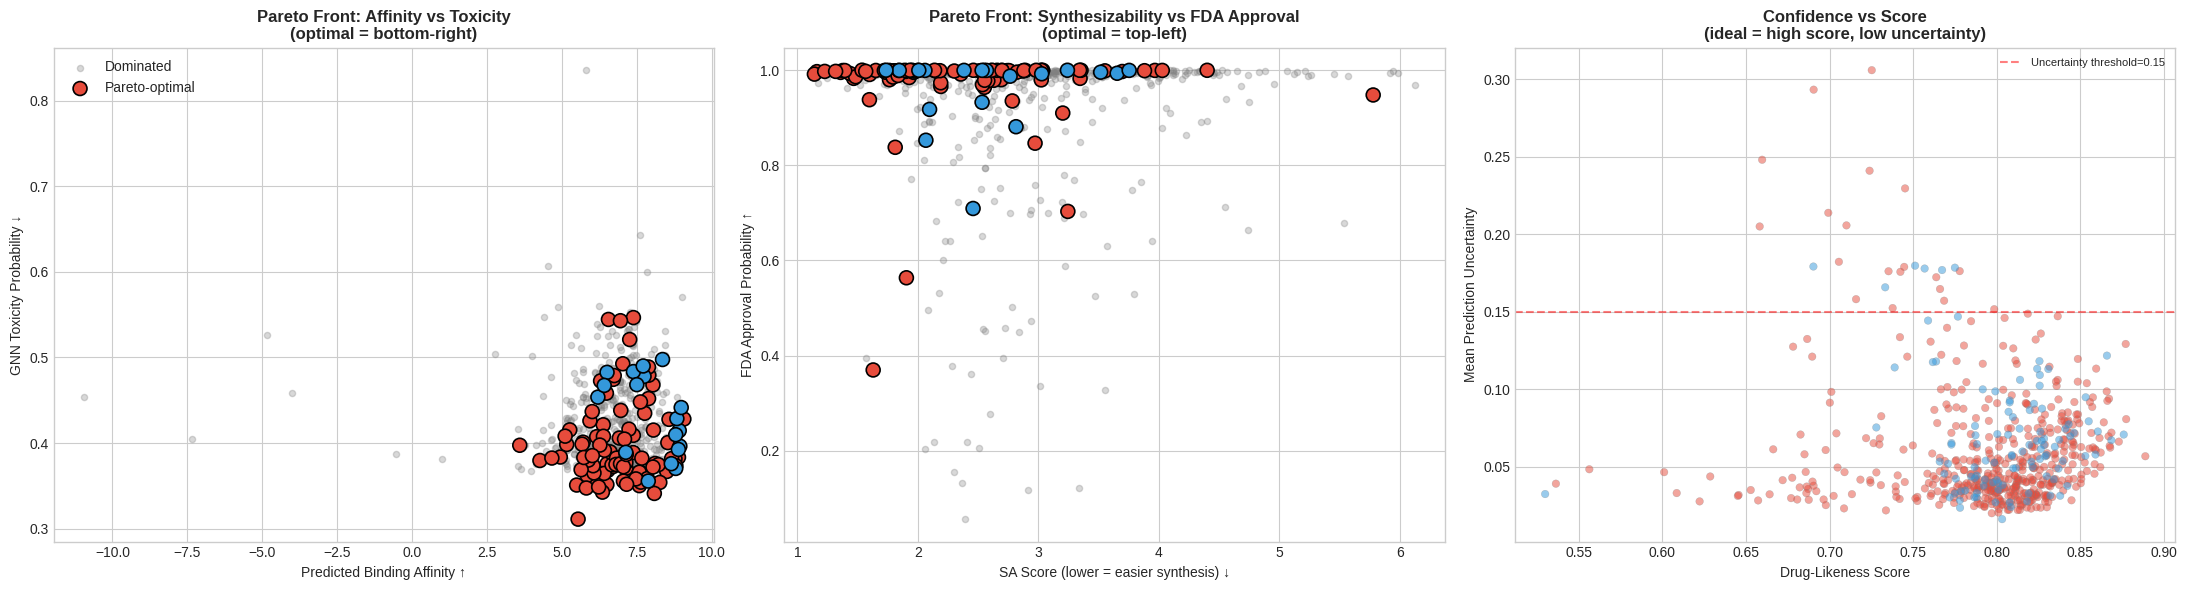

Saved: pareto_front_analysis.png


In [ ]:
# ─── Cell 14f: Pareto Front Analysis (Rich et al. 2024, ACS Med Chem Lett) ───
# Multi-objective drug optimization: efficacy vs safety vs synthesizability
# Pareto-optimal molecules dominate all others on at least one objective

def find_pareto_front(costs):
    """Find Pareto-optimal points (minimize all objectives)."""
    n = len(costs)
    is_pareto = np.ones(n, dtype=bool)
    for i in range(n):
        if not is_pareto[i]:
            continue
        for j in range(n):
            if i == j or not is_pareto[j]:
                continue
            # j dominates i if j <= i on all and j < i on at least one
            if np.all(costs[j] <= costs[i]) and np.any(costs[j] < costs[i]):
                is_pareto[i] = False
                break
    return is_pareto

print('Computing Pareto front for multi-objective optimization...')
all_scored = pd.concat([gen_scored, exist_scored], ignore_index=True)

# Objectives (all to MINIMIZE): toxicity, -affinity, SA difficulty, -FDA_prob
objectives = np.column_stack([
    all_scored['gnn_tox_prob'].values,            # minimize toxicity
    -all_scored['pred_affinity'].values,          # maximize affinity → minimize negative
    all_scored['sa_score'].values / 10.0,         # minimize SA difficulty
    1 - all_scored['fda_approval_prob'].values,   # maximize FDA prob → minimize 1-prob
])

pareto_mask = find_pareto_front(objectives)
all_scored['pareto_optimal'] = pareto_mask

n_pareto = pareto_mask.sum()
n_gen_pareto = all_scored.loc[pareto_mask & (all_scored['source'] == 'generated')].shape[0]
n_exist_pareto = all_scored.loc[pareto_mask & (all_scored['source'] == 'existing')].shape[0]

print(f'Pareto-optimal molecules: {n_pareto} total')
print(f'  Generated on Pareto front:  {n_gen_pareto}')
print(f'  Existing on Pareto front:   {n_exist_pareto}')

# Visualize Pareto front: Affinity vs Toxicity (2D projection)
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Plot 1: Affinity vs Toxicity
ax = axes[0]
non_pareto = all_scored[~all_scored['pareto_optimal']]
pareto_pts = all_scored[all_scored['pareto_optimal']]
ax.scatter(non_pareto['pred_affinity'], non_pareto['gnn_tox_prob'],
           c='gray', alpha=0.3, s=20, label='Dominated')
colors_p = ['#e74c3c' if s == 'generated' else '#3498db'
            for s in pareto_pts['source']]
ax.scatter(pareto_pts['pred_affinity'], pareto_pts['gnn_tox_prob'],
           c=colors_p, s=100, edgecolors='black', linewidth=1.2,
           zorder=5, label='Pareto-optimal')
ax.set_xlabel('Predicted Binding Affinity ↑')
ax.set_ylabel('GNN Toxicity Probability ↓')
ax.set_title('Pareto Front: Affinity vs Toxicity\n(optimal = bottom-right)', fontweight='bold')
ax.legend()

# Plot 2: SA Score vs FDA Probability
ax2 = axes[1]
ax2.scatter(non_pareto['sa_score'], non_pareto['fda_approval_prob'],
            c='gray', alpha=0.3, s=20)
ax2.scatter(pareto_pts['sa_score'], pareto_pts['fda_approval_prob'],
            c=colors_p, s=100, edgecolors='black', linewidth=1.2, zorder=5)
ax2.set_xlabel('SA Score (lower = easier synthesis) ↓')
ax2.set_ylabel('FDA Approval Probability ↑')
ax2.set_title('Pareto Front: Synthesizability vs FDA Approval\n(optimal = top-left)', fontweight='bold')

# Plot 3: Uncertainty vs Drug-likeness (confidence analysis)
ax3 = axes[2]
ax3.scatter(all_scored['drug_likeness_score'],
            (all_scored.get('fda_uncertainty', 0.0) + all_scored.get('tox_uncertainty', 0.0)) / 2,
            c=['#e74c3c' if s == 'generated' else '#3498db' for s in all_scored['source']],
            alpha=0.5, s=30, edgecolors='gray', linewidth=0.3)
ax3.set_xlabel('Drug-Likeness Score')
ax3.set_ylabel('Mean Prediction Uncertainty')
ax3.set_title('Confidence vs Score\n(ideal = high score, low uncertainty)', fontweight='bold')
ax3.axhline(HIGH_UNC_THRESH, color='red', linestyle='--', alpha=0.5, label=f'Uncertainty threshold={HIGH_UNC_THRESH}')
ax3.legend(fontsize=8)

plt.tight_layout()
plt.savefig('pareto_front_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pareto_front_analysis.png')

In [ ]:
# ─── Cell 14g: Enhanced Composite Score with Hardened Penalties ───
# Recompute drug-likeness score with MULTIPLICATIVE penalties for structural alerts
# Rationale: additive penalties were too weak — 57% Brenk rate meant most flagged
# molecules still scored high. Multiplicative penalties create real separation.

def compute_enhanced_drug_likeness(df):
    """Enhanced scoring with multiplicative structural-alert penalties."""
    score = pd.Series(0.0, index=df.index)

    # Original components (same weights)
    aff = df['pred_affinity']
    aff_norm = (aff - aff.min()) / (aff.max() - aff.min() + 1e-8)
    score += aff_norm * 0.25                           # Binding affinity
    score += (1 - df['gnn_tox_prob']) * 0.18           # GNN toxicity
    score += df['fda_approval_prob'] * 0.12            # FDA approval
    score += (1 - df['tox21_mean_tox']) * 0.10         # Tox21 safety
    score += df['QED'] * 0.10                          # QED
    score += (1 - df['lipinski_violations'] / 4).clip(0, 1) * 0.05
    score += df['veber_pass'].astype(float) * 0.05
    sa_norm = 1 - (df['sa_score'] - 1) / 9.0
    score += sa_norm.clip(0, 1) * 0.05
    # Novelty bonus
    if 'is_novel' in df.columns:
        score += df['is_novel'].astype(float) * 0.03

    # HARDENED MULTIPLICATIVE PENALTIES
    # Brenk alert: score *= 0.5 (was -0.03 additive)
    if 'brenk_alert' in df.columns:
        brenk_mult = 1.0 - df['brenk_alert'].astype(float) * 0.5
        score = score * brenk_mult
    # PAINS alert: score *= 0.7
    if 'pains_alert' in df.columns:
        pains_mult = 1.0 - df['pains_alert'].astype(float) * 0.3
        score = score * pains_mult
    # Uncertainty: up to score *= 0.8 for highest uncertainty
    if 'fda_uncertainty' in df.columns:
        avg_unc = (df['fda_uncertainty'] + df['tox_uncertainty']) / 2
        unc_mult = 1 - avg_unc.clip(0, 0.5) * 0.4
        score = score * unc_mult
    # Tox21 alerts: up to score *= 0.85 for 12/12 alerts
    if 'tox21_alerts' in df.columns:
        tox21_mult = 1 - (df['tox21_alerts'] / 12).clip(0, 1) * 0.15
        score = score * tox21_mult

    return score.clip(0, 1)

gen_scored['enhanced_score'] = compute_enhanced_drug_likeness(gen_scored)
exist_scored['enhanced_score'] = compute_enhanced_drug_likeness(exist_scored)
gen_scored = gen_scored.sort_values('enhanced_score', ascending=False).reset_index(drop=True)
exist_scored = exist_scored.sort_values('enhanced_score', ascending=False).reset_index(drop=True)

# Report impact
n_gen_brenk = gen_scored['brenk_alert'].sum() if 'brenk_alert' in gen_scored.columns else 0
n_gen_clean = len(gen_scored) - n_gen_brenk
n_exist_brenk = exist_scored['brenk_alert'].sum() if 'brenk_alert' in exist_scored.columns else 0
n_exist_clean = len(exist_scored) - n_exist_brenk
print('Enhanced Scores with Hardened Multiplicative Penalties:')
print(f'  Brenk: x0.5 | PAINS: x0.7 | Uncertainty: up to x0.8 | Tox21: up to x0.85')
print(f'\n  Generated: {n_gen_clean}/{len(gen_scored)} clean ({100*n_gen_clean/len(gen_scored):.0f}%)')
if n_gen_brenk > 0:
    print(f'    Mean enhanced (clean):   {gen_scored[~gen_scored["brenk_alert"]]["enhanced_score"].mean():.4f}')
    print(f'    Mean enhanced (flagged): {gen_scored[gen_scored["brenk_alert"]]["enhanced_score"].mean():.4f}')
print(f'  Existing: {n_exist_clean}/{len(exist_scored)} clean ({100*n_exist_clean/len(exist_scored):.0f}%)')
print(f'\nTop 5 Generated:')
ecols = ['smiles', 'enhanced_score', 'drug_likeness_score', 'pains_alert', 'brenk_alert', 'tox21_alerts']
acols = [c for c in ecols if c in gen_scored.columns]
print(gen_scored[acols].head(5).to_string(index=False))
print(f'\nTop 5 Existing:')
print(exist_scored[acols].head(5).to_string(index=False))

Enhanced Scores with Hardened Multiplicative Penalties:
  Brenk: x0.5 | PAINS: x0.7 | Uncertainty: up to x0.8 | Tox21: up to x0.85

  Generated: 211/489 clean (43%)
    Mean enhanced (clean):   0.7332
    Mean enhanced (flagged): 0.3486
  Existing: 68/106 clean (64%)

Top 5 Generated:
                                 smiles  enhanced_score  drug_likeness_score  pains_alert  brenk_alert  tox21_alerts
  CN(C(=O)c1ccc(S(N)(=O)=O)cc1)C1CCCCC1        0.808936             0.888955        False        False             0
            Cc1ccc(CNC(=O)C2CCCC2CN)nc1        0.792092             0.873105        False        False             0
   CCc1ccc(S(=O)(=O)N2CCCC(CN)C2)c(C)c1        0.791611             0.877497        False        False             0
CC(=O)N[C@H](C)C(=O)CCC(=O)Nc1ccc(C)cc1        0.788020             0.867932        False        False             0
CC(C)(C)OC(=O)Cc1cc(C(=O)O)ccc1C(C)(C)C        0.787449             0.867620        False        False             0

Top 5 Exist

In [ ]:
# ─── Cell 14h: Target-Specific Docking Integration ───
# The Optim pipeline produced docking scores for existing candidates against 5 targets.
# Integrate these into our v2 scoring — v2 was ignoring target information entirely.
# Targets: ADA (adenosine deaminase), ALDR (aldose reductase), CAH2 (carbonic anhydrase II),
#          TRYB1 (trypsin beta-1), TRY1 (trypsin-1)

print('Integrating target-specific docking scores from Optim pipeline...')

# Load Optim existing with docking info
optim_existing = pd.read_csv(f'{MODEL_DIR}existing_candidates_ranked.csv')
optim_generated = pd.read_csv(f'{MODEL_DIR}generated_candidates.csv')

# Create canonical SMILES lookup for docking scores
docking_lookup = {}
target_lookup = {}
optim_score_lookup = {}
for _, row in optim_existing.iterrows():
    mol = Chem.MolFromSmiles(str(row['smiles']))
    if mol:
        canon = Chem.MolToSmiles(mol)
        docking_lookup[canon] = row['docking_score']
        target_lookup[canon] = row['target']
        optim_score_lookup[canon] = row['optimization_score']

# Also get Optim optimization scores for generated molecules
for _, row in optim_generated.iterrows():
    mol = Chem.MolFromSmiles(str(row['smiles']))
    if mol:
        canon = Chem.MolToSmiles(mol)
        optim_score_lookup[canon] = row['optimization_score']

print(f'Docking scores available for {len(docking_lookup)} existing molecules')
print(f'Optim scores available for {len(optim_score_lookup)} total molecules')

# Map to existing_scored
for df_mol, name in [(gen_scored, 'Generated'), (exist_scored, 'Existing')]:
    dock_vals, tgt_vals, opt_vals = [], [], []
    for smi in df_mol['smiles']:
        mol = Chem.MolFromSmiles(str(smi))
        if mol:
            canon = Chem.MolToSmiles(mol)
            dock_vals.append(docking_lookup.get(canon, np.nan))
            tgt_vals.append(target_lookup.get(canon, 'unknown'))
            opt_vals.append(optim_score_lookup.get(canon, np.nan))
        else:
            dock_vals.append(np.nan)
            tgt_vals.append('unknown')
            opt_vals.append(np.nan)

    df_mol['docking_score'] = dock_vals
    df_mol['target'] = tgt_vals
    df_mol['optim_score'] = opt_vals

    n_dock = pd.notna(pd.Series(dock_vals)).sum()
    n_opt = pd.notna(pd.Series(opt_vals)).sum()
    print(f'  {name}: {n_dock} with docking scores, {n_opt} with optim scores')

# Per-target analysis for existing candidates
print(f'\n--- Per-Target Analysis (Existing Candidates) ---')
for target in sorted(exist_scored['target'].unique()):
    if target == 'unknown':
        continue
    subset = exist_scored[exist_scored['target'] == target]
    print(f'\n  Target: {target.upper()} ({len(subset)} molecules)')
    print(f'    Mean enhanced_score: {subset["enhanced_score"].mean():.4f}')
    print(f'    Mean docking_score:  {subset["docking_score"].mean():.2f}')
    print(f'    Mean pred_affinity:  {subset["pred_affinity"].mean():.3f}')
    print(f'    Mean gnn_tox_prob:   {subset["gnn_tox_prob"].mean():.3f}')
    best = subset.nlargest(1, 'enhanced_score').iloc[0]
    print(f'    Best candidate: {best["smiles"][:50]}...')
    print(f'      enhanced={best["enhanced_score"]:.4f}, dock={best["docking_score"]:.2f}, aff={best["pred_affinity"]:.3f}')

Integrating target-specific docking scores from Optim pipeline...
Docking scores available for 106 existing molecules
Optim scores available for 595 total molecules
  Generated: 0 with docking scores, 489 with optim scores
  Existing: 106 with docking scores, 106 with optim scores

--- Per-Target Analysis (Existing Candidates) ---

  Target: ADA (30 molecules)
    Mean enhanced_score: 0.6563
    Mean docking_score:  -125.02
    Mean pred_affinity:  7.994
    Mean gnn_tox_prob:   0.390
    Best candidate: CN(C)CC(=O)N1CC(NC(=O)c2ccccc2)CC1C(=O)O...
      enhanced=0.7432, dock=-125.00, aff=8.801

  Target: ALDR (30 molecules)
    Mean enhanced_score: 0.5796
    Mean docking_score:  -48.51
    Mean pred_affinity:  8.101
    Mean gnn_tox_prob:   0.460
    Best candidate: O=C(O)[C@H]1CCCN(C(=O)CCN2CCCS2(=O)=O)C1...
      enhanced=0.7621, dock=-45.18, aff=8.801

  Target: CAH2 (30 molecules)
    Mean enhanced_score: 0.4906
    Mean docking_score:  -113.37
    Mean pred_affinity:  6.971
    M

In [ ]:
# ─── Cell 14i: ADMET Prediction (RDKit-Based Descriptors) ───
# Absorption, Distribution, Metabolism, Excretion, Toxicity profiling
# Uses RDKit descriptors as proxies for ADMET properties
# Ref: Lipinski (2004), Veber (2002), Egan (2000), Ghose (1999)

def compute_admet_profile(smiles):
    """Compute ADMET-relevant descriptors using RDKit."""
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return None

    profile = {}
    tpsa = Descriptors.TPSA(mol)
    logp = Descriptors.MolLogP(mol)
    mw = Descriptors.MolWt(mol)

    # ── Absorption proxies ──
    # Egan egg model: good absorption if TPSA <= 131.6 and LogP <= 5.88
    profile['egan_absorption'] = (tpsa <= 131.6) and (logp <= 5.88)
    # Ghose filter: 160 <= MW <= 480, -0.4 <= LogP <= 5.6, 40 <= MR <= 130, 20 <= atoms <= 70
    mr = Descriptors.MolMR(mol)
    n_atoms = mol.GetNumAtoms()
    profile['ghose_pass'] = (160 <= mw <= 480) and (-0.4 <= logp <= 5.6) and \
                            (40 <= mr <= 130) and (20 <= n_atoms <= 70)

    # ── Distribution proxies ──
    profile['bbb_penetrant'] = (tpsa < 90) and (mw < 400)
    profile['ppb_risk'] = logp > 4.0

    # ── Metabolism proxies ──
    n_aromatic = Descriptors.NumAromaticRings(mol)
    n_heavy = Descriptors.HeavyAtomCount(mol)
    profile['cyp_aromatic_risk'] = n_aromatic >= 3
    profile['cyp_lipophilic_risk'] = (logp > 3.0) and (n_heavy < 25)
    fsp3 = Descriptors.FractionCSP3(mol)
    profile['metabolic_stability'] = fsp3 > 0.25

    # ── Excretion proxies ──
    profile['renal_clearance_likely'] = (mw < 300) and (logp < 2.0)

    # ── Overall ADMET traffic light ──
    passes = sum([
        profile['egan_absorption'],
        profile['ghose_pass'],
        not profile['ppb_risk'],
        not profile['cyp_aromatic_risk'],
        profile['metabolic_stability'],
    ])
    profile['admet_score'] = passes / 5.0

    return profile

print('Computing ADMET profiles for all candidates...')
for df_mol, name in [(gen_scored, 'Generated'), (exist_scored, 'Existing')]:
    admet_profiles = []
    for smi in tqdm(df_mol['smiles'], desc=f'{name} ADMET'):
        profile = compute_admet_profile(smi)
        if profile is None:
            profile = {k: False for k in ['egan_absorption', 'ghose_pass', 'bbb_penetrant',
                       'ppb_risk', 'cyp_aromatic_risk', 'cyp_lipophilic_risk',
                       'metabolic_stability', 'renal_clearance_likely']}
            profile['admet_score'] = 0.0
        admet_profiles.append(profile)

    admet_df = pd.DataFrame(admet_profiles)
    # Only assign new ADMET columns — don't overwrite existing TPSA/LogP/MW
    for col in admet_df.columns:
        if col not in df_mol.columns:
            df_mol[col] = admet_df[col].values

    print(f'\n  {name} ADMET Summary:')
    print(f'    Egan absorption pass:     {df_mol["egan_absorption"].sum()}/{len(df_mol)}')
    print(f'    Ghose filter pass:        {df_mol["ghose_pass"].sum()}/{len(df_mol)}')
    print(f'    BBB penetrant:            {df_mol["bbb_penetrant"].sum()}/{len(df_mol)}')
    print(f'    PPB risk (high):          {df_mol["ppb_risk"].sum()}/{len(df_mol)}')
    print(f'    CYP aromatic risk:        {df_mol["cyp_aromatic_risk"].sum()}/{len(df_mol)}')
    print(f'    Metabolic stability:      {df_mol["metabolic_stability"].sum()}/{len(df_mol)}')
    print(f'    Mean ADMET score:         {df_mol["admet_score"].mean():.3f}')

Computing ADMET profiles for all candidates...


Generated ADMET:   0%|          | 0/489 [00:00<?, ?it/s]


  Generated ADMET Summary:
    Egan absorption pass:     456/489
    Ghose filter pass:        118/489
    BBB penetrant:            394/489
    PPB risk (high):          84/489
    CYP aromatic risk:        4/489
    Metabolic stability:      377/489
    Mean ADMET score:         0.753


Existing ADMET:   0%|          | 0/106 [00:00<?, ?it/s]


  Existing ADMET Summary:
    Egan absorption pass:     106/106
    Ghose filter pass:        55/106
    BBB penetrant:            87/106
    PPB risk (high):          8/106
    CYP aromatic risk:        1/106
    Metabolic stability:      100/106
    Mean ADMET score:         0.875


In [ ]:
# ─── Cell 14j: Murcko Scaffold Analysis ───
# Decompose molecules into Murcko scaffolds to assess chemical diversity
# If top candidates share scaffolds, we're really only exploring 2-3 chemical series

def get_murcko_scaffold(smiles):
    """Get the Murcko (Bemis-Murcko) generic scaffold of a molecule."""
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return None
    try:
        scaffold = MurckoScaffold.GetScaffoldForMol(mol)
        generic = MurckoScaffold.MakeScaffoldGeneric(scaffold)
        return Chem.MolToSmiles(generic)
    except Exception:
        return None

print('Performing Murcko scaffold analysis...')
for df_mol, name in [(gen_scored, 'Generated'), (exist_scored, 'Existing')]:
    scaffolds = []
    for smi in df_mol['smiles']:
        scaffolds.append(get_murcko_scaffold(smi))
    df_mol['murcko_scaffold'] = scaffolds

    valid_scaffolds = [s for s in scaffolds if s is not None]
    unique_scaffolds = set(valid_scaffolds)
    print(f'\n  {name}:')
    print(f'    Total molecules:    {len(df_mol)}')
    print(f'    Valid scaffolds:    {len(valid_scaffolds)}')
    print(f'    Unique scaffolds:   {len(unique_scaffolds)}')
    print(f'    Scaffold diversity: {len(unique_scaffolds)/max(len(valid_scaffolds),1):.3f}')

    # Top 10 most common scaffolds
    scaffold_counts = pd.Series(valid_scaffolds).value_counts()
    print(f'    Top 5 scaffolds:')
    for scaffold, count in scaffold_counts.head(5).items():
        pct = 100 * count / len(valid_scaffolds)
        print(f'      {scaffold[:50]:50s} → {count} molecules ({pct:.1f}%)')

# Scaffold analysis for TOP 30 candidates
print('\n--- Scaffold Diversity in Top 30 Candidates ---')
all_for_scaffold = pd.concat([gen_scored, exist_scored], ignore_index=True)
all_for_scaffold = all_for_scaffold.sort_values('enhanced_score', ascending=False)
top30 = all_for_scaffold.head(30)
top30_scaffolds = top30['murcko_scaffold'].dropna()
unique_top30 = top30_scaffolds.nunique()
print(f'  Top 30 molecules span {unique_top30} unique scaffolds')

if unique_top30 < 10:
    print(f'  ⚠ Low scaffold diversity! Top 30 only covers {unique_top30} scaffolds.')
    print(f'    Consider enforcing scaffold diversity in final selection.')
else:
    print(f'  ✓ Reasonable scaffold diversity ({unique_top30} scaffolds in top 30)')

# Scaffold-diverse selection: pick best molecule per scaffold
print('\n--- Scaffold-Diverse Best Candidates ---')
scaffold_best = all_for_scaffold.dropna(subset=['murcko_scaffold']).groupby('murcko_scaffold').first()
scaffold_best = scaffold_best.sort_values('enhanced_score', ascending=False)
diverse_top = scaffold_best.head(20)
print(f'Top 20 scaffold-diverse candidates (1 per scaffold, ranked by enhanced_score):')
diverse_cols = ['enhanced_score', 'QED', 'gnn_tox_prob', 'pred_affinity',
                'fda_approval_prob', 'pains_alert', 'brenk_alert', 'admet_score']
available_diverse = [c for c in diverse_cols if c in diverse_top.columns]
print(diverse_top[available_diverse].head(20).to_string())

Performing Murcko scaffold analysis...

  Generated:
    Total molecules:    489
    Valid scaffolds:    489
    Unique scaffolds:   114
    Scaffold diversity: 0.233
    Top 5 scaffolds:
                                                         → 207 molecules (42.3%)
      C1CCCCC1                                           → 119 molecules (24.3%)
      CC(C)(CC1CCCCC1)C1CCCCC1                           → 13 molecules (2.7%)
      C1CCCCCC1                                          → 7 molecules (1.4%)
      C1CCCC1                                            → 7 molecules (1.4%)

  Existing:
    Total molecules:    106
    Valid scaffolds:    106
    Unique scaffolds:   55
    Scaffold diversity: 0.519
    Top 5 scaffolds:
      C1CCCCC1                                           → 24 molecules (22.6%)
                                                         → 12 molecules (11.3%)
      C1CCCC1                                            → 7 molecules (6.6%)
      C1CCC(C2CCCC2)CC1       

Performing chemical diversity analysis...


[18:46:03] DEPRECATION WARNING: please use MorganGenerator
[18:46:03] DEPRECATION WARNING: please use MorganGenerator
[18:46:03] DEPRECATION WARNING: please use MorganGenerator
[18:46:03] DEPRECATION WARNING: please use MorganGenerator
[18:46:03] DEPRECATION WARNING: please use MorganGenerator
[18:46:03] DEPRECATION WARNING: please use MorganGenerator
[18:46:03] DEPRECATION WARNING: please use MorganGenerator
[18:46:03] DEPRECATION WARNING: please use MorganGenerator
[18:46:03] DEPRECATION WARNING: please use MorganGenerator
[18:46:03] DEPRECATION WARNING: please use MorganGenerator
[18:46:03] DEPRECATION WARNING: please use MorganGenerator
[18:46:03] DEPRECATION WARNING: please use MorganGenerator
[18:46:03] DEPRECATION WARNING: please use MorganGenerator
[18:46:03] DEPRECATION WARNING: please use MorganGenerator
[18:46:03] DEPRECATION WARNING: please use MorganGenerator
[18:46:03] DEPRECATION WARNING: please use MorganGenerator
[18:46:03] DEPRECATION WARNING: please use MorganGenerat


Tanimoto Diversity (higher = more diverse, max 1.0):
  Generated internal:     0.9031
  Existing internal:      0.8706
  Cross (gen vs exist):   0.8956


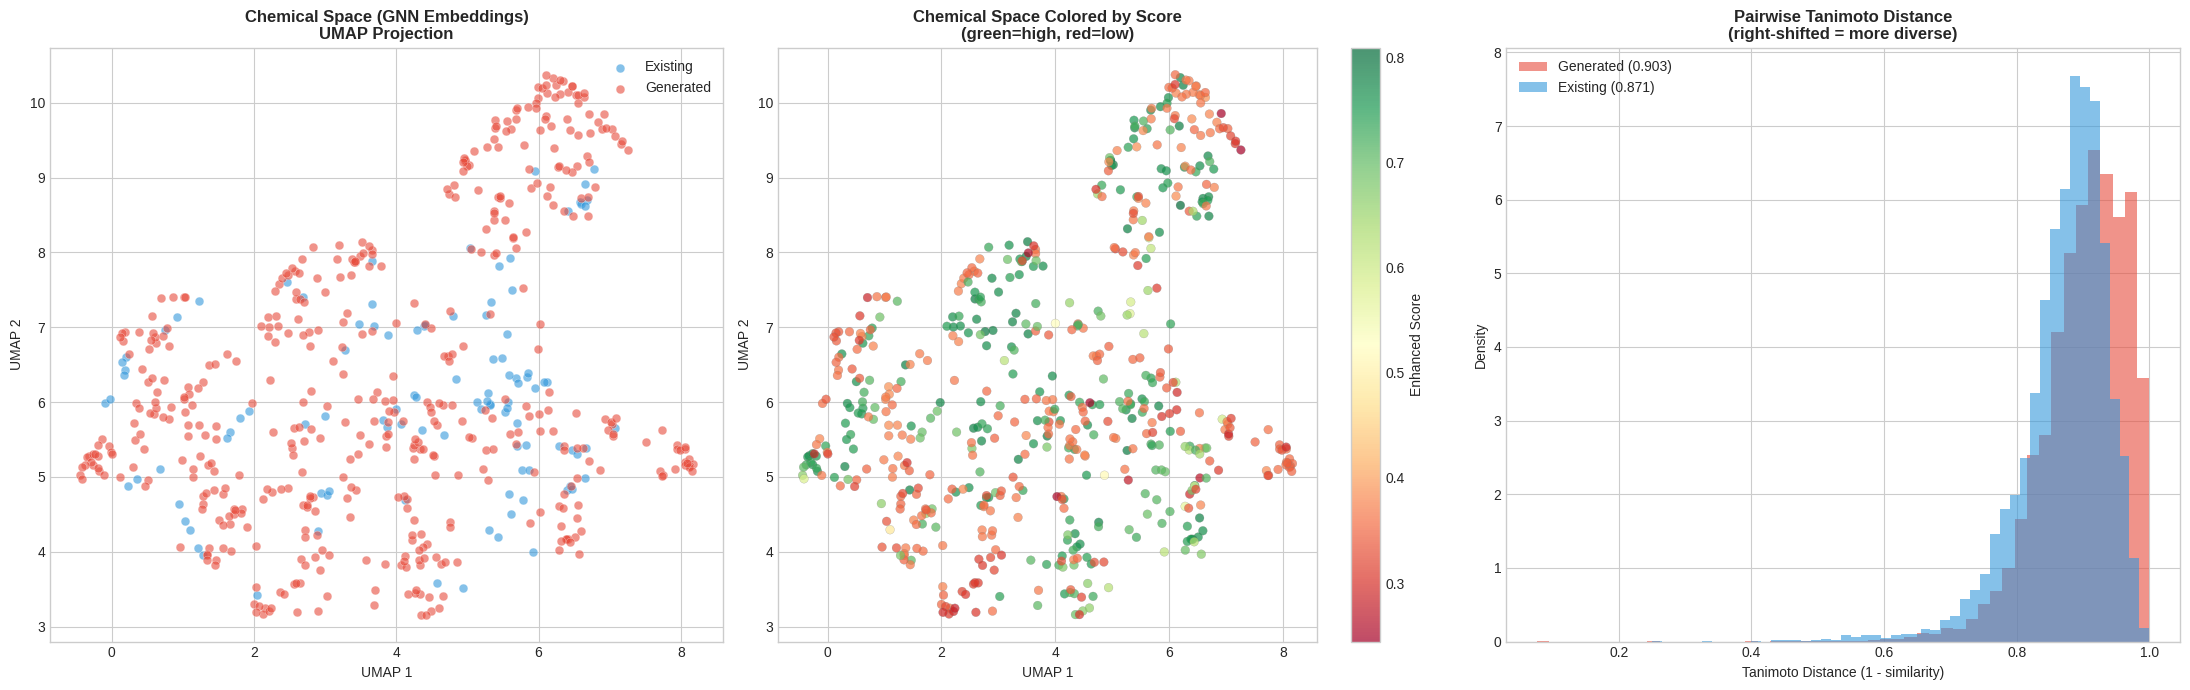

Saved: chemical_diversity_analysis.png


In [ ]:
# ─── Cell 14k: Chemical Diversity Analysis (UMAP + Tanimoto) ───
# Use GNN embeddings + Morgan fingerprints to analyze chemical space coverage
# Molecules clustered in a tiny region = low diversity, limited exploration

print('Performing chemical diversity analysis...')

all_diversity = pd.concat([gen_scored, exist_scored], ignore_index=True)

# ── 1: UMAP on GNN embeddings ──
gnn_cols = [c for c in all_diversity.columns if c.startswith('gnn_emb_')]
gnn_matrix = all_diversity[gnn_cols].fillna(0).values

reducer = umap.UMAP(n_components=2, random_state=RANDOM_STATE, n_neighbors=15, min_dist=0.1)
umap_coords = reducer.fit_transform(gnn_matrix)
all_diversity['umap_x'] = umap_coords[:, 0]
all_diversity['umap_y'] = umap_coords[:, 1]

# Also store in gen_scored / exist_scored
n_gen = len(gen_scored)
gen_scored['umap_x'] = umap_coords[:n_gen, 0]
gen_scored['umap_y'] = umap_coords[:n_gen, 1]
exist_scored['umap_x'] = umap_coords[n_gen:, 0]
exist_scored['umap_y'] = umap_coords[n_gen:, 1]

# ── 2: Tanimoto diversity ──
def compute_tanimoto_diversity(smiles_list, sample_size=200):
    """Compute mean pairwise Tanimoto distance (1 - similarity)."""
    fps = []
    for smi in smiles_list[:sample_size]:
        mol = Chem.MolFromSmiles(str(smi))
        if mol:
            fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=2048)
            fps.append(fp)
    if len(fps) < 2:
        return 0.0, []

    # Compute pairwise Tanimoto similarities
    sims = []
    for i in range(len(fps)):
        for j in range(i+1, len(fps)):
            sims.append(DataStructs.TanimotoSimilarity(fps[i], fps[j]))
    distances = [1 - s for s in sims]
    return np.mean(distances), distances

gen_div, gen_dists = compute_tanimoto_diversity(gen_scored['smiles'].tolist())
exist_div, exist_dists = compute_tanimoto_diversity(exist_scored['smiles'].tolist())
cross_div_fps_gen = []
cross_div_fps_exist = []
for smi in gen_scored['smiles'].head(100):
    mol = Chem.MolFromSmiles(str(smi))
    if mol:
        cross_div_fps_gen.append(AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=2048))
for smi in exist_scored['smiles'].head(100):
    mol = Chem.MolFromSmiles(str(smi))
    if mol:
        cross_div_fps_exist.append(AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=2048))

cross_sims = []
for fp_g in cross_div_fps_gen:
    for fp_e in cross_div_fps_exist:
        cross_sims.append(DataStructs.TanimotoSimilarity(fp_g, fp_e))
cross_div = 1 - np.mean(cross_sims) if cross_sims else 0

print(f'\nTanimoto Diversity (higher = more diverse, max 1.0):')
print(f'  Generated internal:     {gen_div:.4f}')
print(f'  Existing internal:      {exist_div:.4f}')
print(f'  Cross (gen vs exist):   {cross_div:.4f}')

# ── 3: UMAP visualization ──
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# Plot 1: UMAP colored by source
ax = axes[0]
gen_mask = all_diversity['source'] == 'generated'
ax.scatter(all_diversity.loc[~gen_mask, 'umap_x'], all_diversity.loc[~gen_mask, 'umap_y'],
           c='#3498db', alpha=0.6, s=40, label='Existing', edgecolors='white', linewidth=0.3)
ax.scatter(all_diversity.loc[gen_mask, 'umap_x'], all_diversity.loc[gen_mask, 'umap_y'],
           c='#e74c3c', alpha=0.6, s=40, label='Generated', edgecolors='white', linewidth=0.3)
ax.set_title('Chemical Space (GNN Embeddings)\nUMAP Projection', fontweight='bold')
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.legend()

# Plot 2: UMAP colored by enhanced score
ax2 = axes[1]
sc = ax2.scatter(all_diversity['umap_x'], all_diversity['umap_y'],
                 c=all_diversity['enhanced_score'], cmap='RdYlGn', s=40,
                 alpha=0.7, edgecolors='gray', linewidth=0.2)
plt.colorbar(sc, ax=ax2, label='Enhanced Score')
ax2.set_title('Chemical Space Colored by Score\n(green=high, red=low)', fontweight='bold')
ax2.set_xlabel('UMAP 1'); ax2.set_ylabel('UMAP 2')

# Plot 3: Tanimoto distance distributions
ax3 = axes[2]
if gen_dists:
    ax3.hist(gen_dists, bins=50, alpha=0.6, color='#e74c3c', label=f'Generated ({gen_div:.3f})', density=True)
if exist_dists:
    ax3.hist(exist_dists, bins=50, alpha=0.6, color='#3498db', label=f'Existing ({exist_div:.3f})', density=True)
ax3.set_xlabel('Tanimoto Distance (1 - similarity)')
ax3.set_ylabel('Density')
ax3.set_title('Pairwise Tanimoto Distance\n(right-shifted = more diverse)', fontweight='bold')
ax3.legend()

plt.tight_layout()
plt.savefig('chemical_diversity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: chemical_diversity_analysis.png')

In [ ]:
# ─── Cell 14l: Final Candidate Selection — Scaffold-Diverse, All Filters ───
# Apply ALL filters and enforce scaffold diversity for the final shortlist
# This is the "money list" — candidates worth experimental follow-up

print('=' * 70)
print('  FINAL CANDIDATE SELECTION')
print('  Applying all filters + scaffold diversity enforcement')
print('=' * 70)

all_final = pd.concat([gen_scored, exist_scored], ignore_index=True)

# ── Strict filtering ──
mask_clean = (
    (~all_final['pains_alert']) &
    (~all_final['brenk_alert']) &
    (~all_final['high_uncertainty']) &
    (all_final['tox21_alerts'] == 0) &
    (all_final['lipinski_violations'] <= 1) &
    (all_final['QED'] >= 0.4) &
    (all_final['fda_approval_prob'] >= 0.7) &
    (all_final['gnn_tox_prob'] < 0.5) &
    (all_final['sa_score'] <= 5.0) &
    (all_final['egan_absorption'] == True)
)
clean_candidates = all_final[mask_clean].copy()
clean_candidates = clean_candidates.sort_values('enhanced_score', ascending=False)

print(f'\nAfter strict filtering: {len(clean_candidates)}/{len(all_final)} candidates remain')
print(f'  Sources: {clean_candidates["source"].value_counts().to_dict()}')

# ── Scaffold-diverse selection (top 1 per scaffold) ──
scaffold_diverse = []
seen_scaffolds = set()
for _, row in clean_candidates.iterrows():
    scaffold = row.get('murcko_scaffold', None)
    # Handle NaN scaffolds (pandas stores None as NaN)
    if pd.isna(scaffold):
        scaffold_diverse.append(row)  # keep molecules without scaffold info
    elif scaffold not in seen_scaffolds:
        scaffold_diverse.append(row)
        seen_scaffolds.add(scaffold)

    if len(scaffold_diverse) >= 30:
        break

final_candidates = pd.DataFrame(scaffold_diverse)
print(f'Scaffold-diverse final selection: {len(final_candidates)} candidates')
print(f'  Unique scaffolds: {len(seen_scaffolds)}')

# Display final shortlist
print(f'\n{"="*70}')
print(f'  TOP CANDIDATES FOR EXPERIMENTAL VALIDATION')
print(f'{"="*70}')
display_cols_final = ['smiles', 'source', 'enhanced_score', 'QED', 'pred_affinity',
                      'fda_approval_prob', 'gnn_tox_prob', 'sa_score', 'admet_score',
                      'murcko_scaffold']
avail_cols_final = [c for c in display_cols_final if c in final_candidates.columns]
print(final_candidates[avail_cols_final].head(20).to_string(index=False))

  FINAL CANDIDATE SELECTION
  Applying all filters + scaffold diversity enforcement

After strict filtering: 162/595 candidates remain
  Sources: {'generated': 129, 'existing': 33}
Scaffold-diverse final selection: 30 candidates
  Unique scaffolds: 30

  TOP CANDIDATES FOR EXPERIMENTAL VALIDATION
                                  smiles    source  enhanced_score      QED  pred_affinity  fda_approval_prob  gnn_tox_prob  sa_score  admet_score                  murcko_scaffold
   CN(C(=O)c1ccc(S(N)(=O)=O)cc1)C1CCCCC1 generated        0.808936 0.922174       8.502624           0.998018      0.366698  1.929451          1.0            CC(CC1CCCCC1)C1CCCCC1
             Cc1ccc(CNC(=O)C2CCCC2CN)nc1 generated        0.792092 0.844325       7.894542           0.993376      0.371331  2.984972          0.8            CC(CCC1CCCCC1)C1CCCC1
    CCc1ccc(S(=O)(=O)N2CCCC(CN)C2)c(C)c1 generated        0.791611 0.922969       8.190883           0.969413      0.372269  2.580045          1.0          CC(C)(

Generating 3D conformers for final candidates...
  Successfully generated 3D conformers for 30/30 molecules
  Saved: final_candidates_3d.sdf (30 molecules with 3D coordinates)
  Saved: final_candidates_filtered.csv

Top 12 final candidates (2D structures):


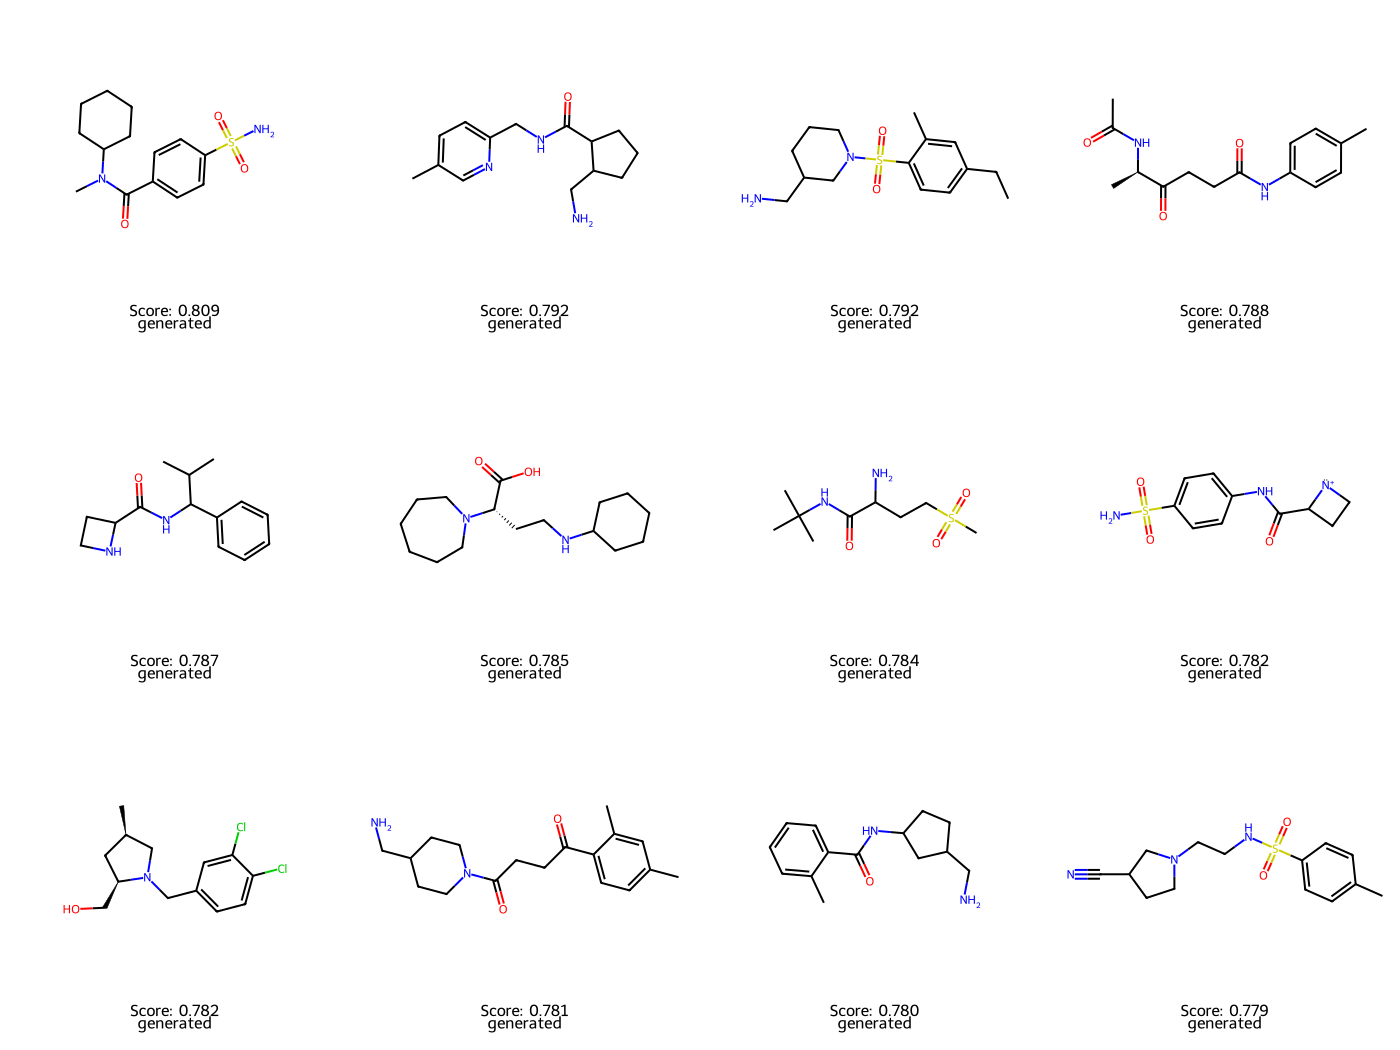

Saved: final_candidates_structures.png

--- Docking Ready ---
  SDF file: final_candidates_3d.sdf (load into AutoDock Vina / DiffDock)
  Target proteins from Optim: ADA, ALDR, CAH2, TRYB1, TRY1
  Recommended: dock against all 5 targets, rank by binding energy


In [ ]:
# ─── Cell 14m: Docking Preparation — 3D Conformers + SDF Export ───
# Generate 3D conformers for top candidates and export as SDF for docking with AutoDock Vina
# Ref: Eberhardt et al. (2021) AutoDock Vina 1.2.0

from rdkit.Chem import Draw

def generate_3d_conformer(smiles, n_conformers=1):
    """Generate 3D conformer using ETKDG and MMFF optimization."""
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return None
    mol = Chem.AddHs(mol)
    params = AllChem.ETKDGv3()
    params.randomSeed = RANDOM_STATE
    conf_ids = AllChem.EmbedMultipleConfs(mol, numConfs=n_conformers, params=params)
    if len(conf_ids) == 0:
        # Fallback: try single embed
        res = AllChem.EmbedMolecule(mol, randomSeed=RANDOM_STATE)
        if res == -1 or mol.GetNumConformers() == 0:
            return None
    # MMFF optimization
    try:
        for conf_id in range(mol.GetNumConformers()):
            AllChem.MMFFOptimizeMolecule(mol, confId=conf_id, maxIters=500)
    except Exception:
        pass
    return mol

print('Generating 3D conformers for final candidates...')
mols_3d = []
valid_smiles = []
for i, row in final_candidates.iterrows():
    mol_3d = generate_3d_conformer(row['smiles'])
    if mol_3d is not None:
        mol_3d.SetProp('enhanced_score', f'{row["enhanced_score"]:.4f}')
        mol_3d.SetProp('source', str(row['source']))
        mol_3d.SetProp('QED', f'{row["QED"]:.3f}')
        mol_3d.SetProp('pred_affinity', f'{row["pred_affinity"]:.3f}')
        mol_3d.SetProp('fda_approval_prob', f'{row["fda_approval_prob"]:.3f}')
        mol_3d.SetProp('gnn_tox_prob', f'{row["gnn_tox_prob"]:.3f}')
        if 'admet_score' in row.index:
            mol_3d.SetProp('admet_score', f'{row["admet_score"]:.3f}')
        mols_3d.append(mol_3d)
        valid_smiles.append(row['smiles'])

print(f'  Successfully generated 3D conformers for {len(mols_3d)}/{len(final_candidates)} molecules')

# Export as SDF file for docking
sdf_path = 'final_candidates_3d.sdf'
writer = Chem.SDWriter(sdf_path)
for mol in mols_3d:
    writer.write(mol)
writer.close()
print(f'  Saved: {sdf_path} ({len(mols_3d)} molecules with 3D coordinates)')

# Also export final candidates CSV
final_candidates.to_csv('final_candidates_filtered.csv', index=False)
print(f'  Saved: final_candidates_filtered.csv')

# Generate 2D structure grid of top 12
print("\nTop 12 final candidates (2D structures):")
top_mols_2d = []
legends = []
for _, row in final_candidates.head(12).iterrows():
    mol = Chem.MolFromSmiles(str(row['smiles']))
    if mol:
        top_mols_2d.append(mol)
        legends.append(f"Score: {row['enhanced_score']:.3f}\n{row['source']}")

if top_mols_2d:
    # The filename argument is the most direct way to save in newer RDKit versions in Colab
    img = Draw.MolsToGridImage(list(top_mols_2d), molsPerRow=4, subImgSize=(350, 350), legends=legends, useSVG=False)
    display(img)
    # Directly save using the internal draw engine to avoid AttributeError
    from rdkit.Chem.Draw import rdMolDraw2D
    d2d = rdMolDraw2D.MolDraw2DCairo(1400, 1050, 350, 350)
    d2d.DrawMolecules(list(top_mols_2d), legends=legends)
    d2d.FinishDrawing()
    with open('final_candidates_structures.png', 'wb') as f:
        f.write(d2d.GetDrawingText())
    print('Saved: final_candidates_structures.png')

print(f'\n--- Docking Ready ---')
print(f'  SDF file: {sdf_path} (load into AutoDock Vina / DiffDock)')
print(f'  Target proteins from Optim: ADA, ALDR, CAH2, TRYB1, TRY1')
print(f'  Recommended: dock against all 5 targets, rank by binding energy')

## Part 5: Visualization Dashboard

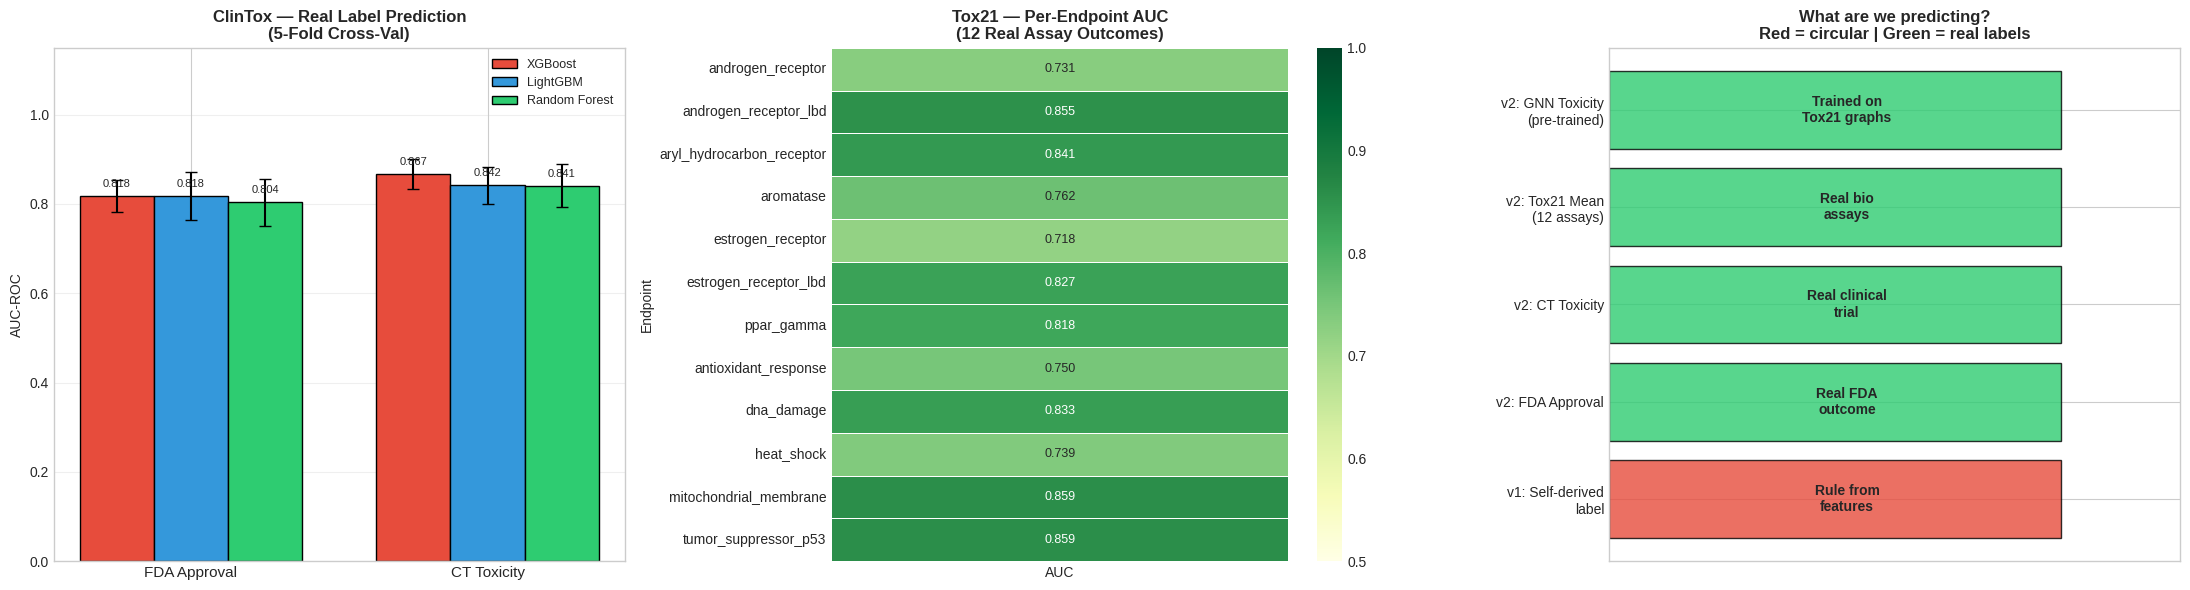

Saved: model_performance_real_labels.png


In [ ]:
# ─── Cell 15: ClinTox & Tox21 Model Performance ───

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# ── 1: ClinTox results bar chart ──
ax = axes[0]
tasks = clintox_results['Task'].unique()
models = clintox_results['Model'].unique()
x = np.arange(len(tasks))
w = 0.25
colors = ['#e74c3c', '#3498db', '#2ecc71']
for i, mdl_name in enumerate(models):
    subset = clintox_results[clintox_results['Model'] == mdl_name]
    aucs = [subset[subset['Task']==t]['AUC_mean'].values[0] for t in tasks]
    stds = [subset[subset['Task']==t]['AUC_std'].values[0] for t in tasks]
    bars = ax.bar(x + i*w, aucs, w, yerr=stds, label=mdl_name,
                  color=colors[i], edgecolor='black', capsize=4)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+0.02, f'{h:.3f}',
                ha='center', fontsize=8)
ax.set_xticks(x + w)
ax.set_xticklabels(['FDA Approval', 'CT Toxicity'], fontsize=11)
ax.set_ylabel('AUC-ROC')
ax.set_title('ClinTox — Real Label Prediction\n(5-Fold Cross-Val)', fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(0, 1.15)
ax.grid(True, alpha=0.3, axis='y')

# ── 2: Tox21 endpoint AUC heatmap ──
ax2 = axes[1]
tox21_hm = tox21_results_df[['Endpoint', 'AUC']].set_index('Endpoint')
sns.heatmap(tox21_hm, annot=True, fmt='.3f', cmap='YlGn',
            ax=ax2, linewidths=0.5, vmin=0.5, vmax=1.0,
            annot_kws={'size': 9})
ax2.set_title('Tox21 — Per-Endpoint AUC\n(12 Real Assay Outcomes)', fontweight='bold')
ax2.tick_params(axis='y', rotation=0)

# ── 3: What we're actually predicting (comparison) ──
ax3 = axes[2]
comparison = pd.DataFrame({
    'Task': ['v1: Self-derived\nlabel', 'v2: FDA Approval', 'v2: CT Toxicity',
             'v2: Tox21 Mean\n(12 assays)', 'v2: GNN Toxicity\n(pre-trained)'],
    'Label Source': ['Rule from\nfeatures', 'Real FDA\noutcome', 'Real clinical\ntrial',
                     'Real bio\nassays', 'Trained on\nTox21 graphs'],
    'Meaningful': [0, 1, 1, 1, 1]
})
colors_bar = ['#e74c3c' if m == 0 else '#2ecc71' for m in comparison['Meaningful']]
bars = ax3.barh(comparison['Task'], [0.95, 0.95, 0.95, 0.95, 0.95],
                color=colors_bar, edgecolor='black', alpha=0.8)
for i, (task, src) in enumerate(zip(comparison['Task'], comparison['Label Source'])):
    ax3.text(0.5, i, src, ha='center', va='center', fontsize=10, fontweight='bold')
ax3.set_xlim(0, 1.2)
ax3.set_title('What are we predicting?\nRed = circular | Green = real labels', fontweight='bold')
ax3.set_xlabel('')
ax3.set_xticks([])

plt.tight_layout()
plt.savefig('model_performance_real_labels.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model_performance_real_labels.png')

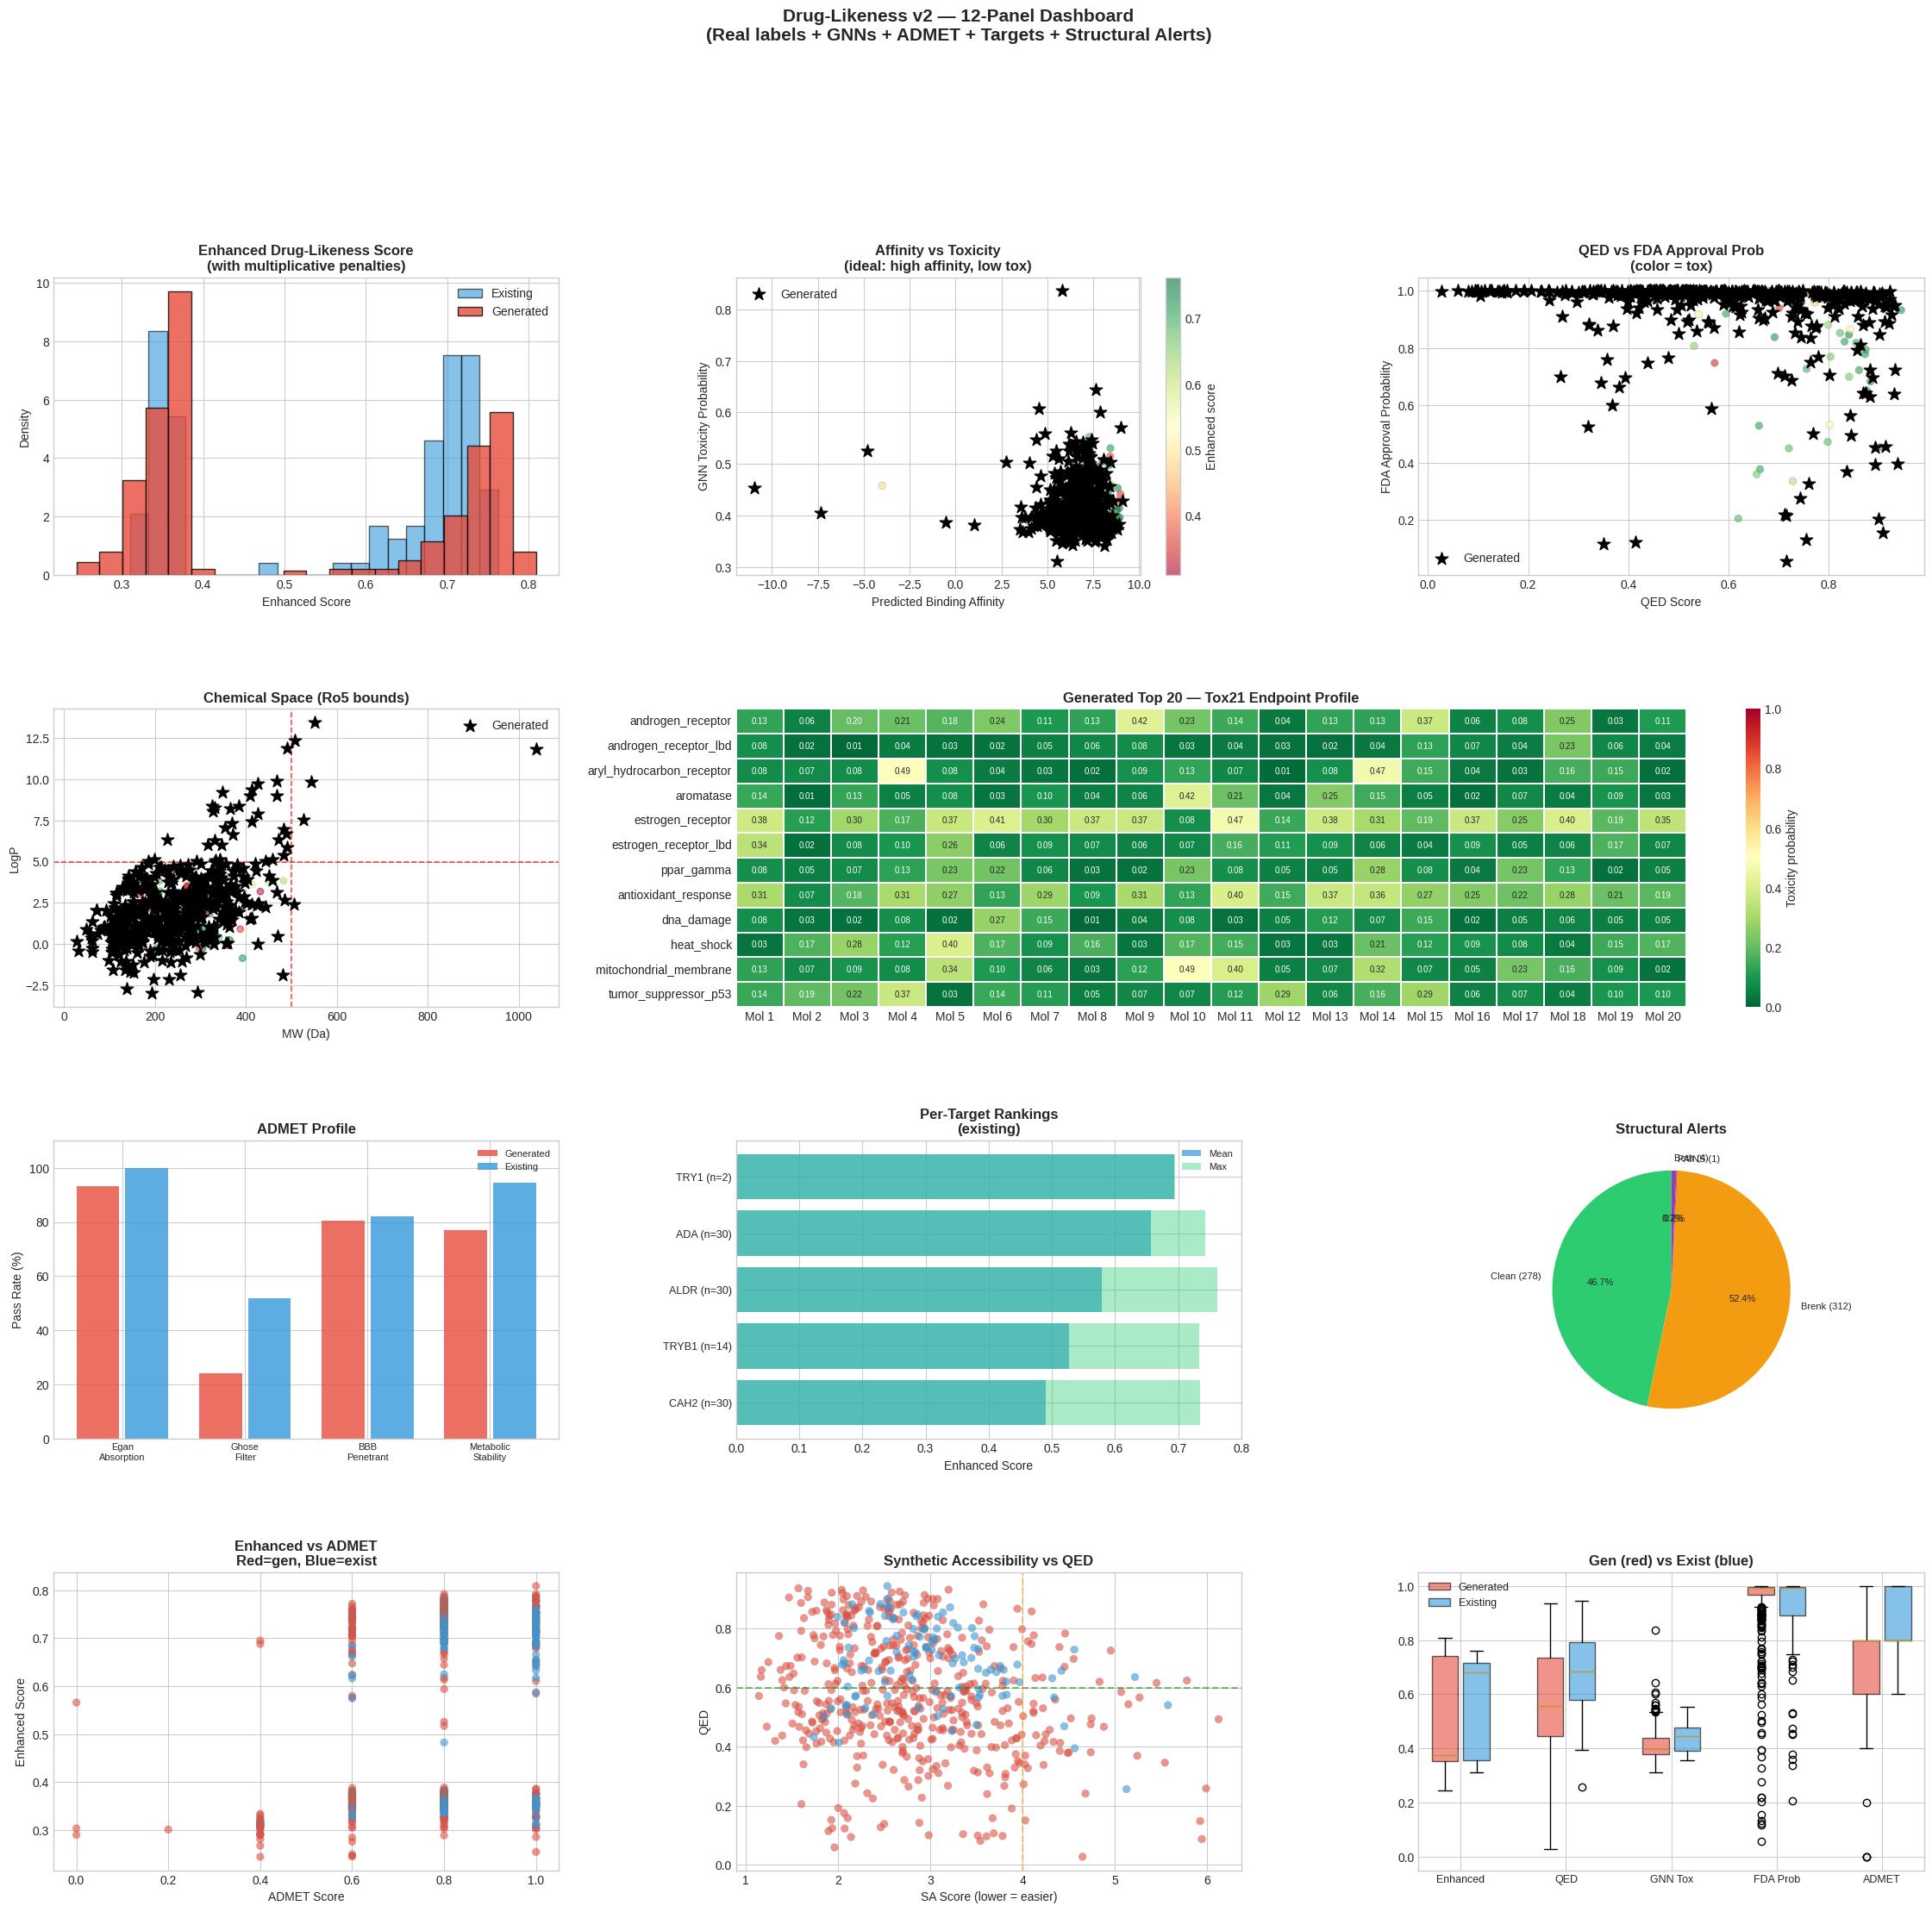

Saved: drug_likeness_v2_dashboard.png


In [ ]:
# ─── Cell 16: Candidate Scoring Dashboard (12-Panel) ───

fig = plt.figure(figsize=(28, 24))
gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.45, wspace=0.35)

all_plot_df = pd.concat([gen_scored, exist_scored], ignore_index=True)

# ── 1: Enhanced score distribution ──
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(exist_scored['enhanced_score'], bins=20, alpha=0.6,
         color='#3498db', edgecolor='black', label='Existing', density=True)
ax1.hist(gen_scored['enhanced_score'], bins=20, alpha=0.8,
         color='#e74c3c', edgecolor='black', label='Generated', density=True)
ax1.set_title('Enhanced Drug-Likeness Score\n(with multiplicative penalties)', fontweight='bold')
ax1.set_xlabel('Enhanced Score'); ax1.set_ylabel('Density')
ax1.legend()

# ── 2: GNN Tox vs Binding Affinity ──
ax2 = fig.add_subplot(gs[0, 1])
sc = ax2.scatter(exist_scored['pred_affinity'], exist_scored['gnn_tox_prob'],
                 c=exist_scored['enhanced_score'], cmap='RdYlGn',
                 alpha=0.6, s=40, edgecolors='gray', linewidth=0.3)
ax2.scatter(gen_scored['pred_affinity'], gen_scored['gnn_tox_prob'],
            c='black', s=120, marker='*', zorder=5, label='Generated')
plt.colorbar(sc, ax=ax2, label='Enhanced score')
ax2.set_xlabel('Predicted Binding Affinity')
ax2.set_ylabel('GNN Toxicity Probability')
ax2.set_title('Affinity vs Toxicity\n(ideal: high affinity, low tox)', fontweight='bold')
ax2.legend()

# ── 3: FDA approval prob vs QED ──
ax3 = fig.add_subplot(gs[0, 2])
ax3.scatter(exist_scored['QED'], exist_scored['fda_approval_prob'],
            c=exist_scored['gnn_tox_prob'], cmap='RdYlGn_r',
            alpha=0.6, s=40, edgecolors='gray', linewidth=0.3)
ax3.scatter(gen_scored['QED'], gen_scored['fda_approval_prob'],
            c='black', s=120, marker='*', zorder=5, label='Generated')
ax3.set_xlabel('QED Score'); ax3.set_ylabel('FDA Approval Probability')
ax3.set_title('QED vs FDA Approval Prob\n(color = tox)', fontweight='bold')
ax3.legend()

# ── 4: MW vs LogP chemical space ──
ax4 = fig.add_subplot(gs[1, 0])
ax4.scatter(exist_scored['MW'], exist_scored['LogP'],
            c=exist_scored['enhanced_score'], cmap='RdYlGn', alpha=0.5, s=30)
ax4.scatter(gen_scored['MW'], gen_scored['LogP'],
            c='black', s=120, marker='*', zorder=5, label='Generated')
ax4.axhline(5, color='red', linestyle='--', lw=1.2, alpha=0.7)
ax4.axvline(500, color='red', linestyle='--', lw=1.2, alpha=0.7)
ax4.set_xlabel('MW (Da)'); ax4.set_ylabel('LogP')
ax4.set_title('Chemical Space (Ro5 bounds)', fontweight='bold')
ax4.legend()

# ── 5: Tox21 endpoint heatmap ──
ax5 = fig.add_subplot(gs[1, 1:])
tox21_ep_cols = [f'tox21_{ep}' for ep in TOX21_ENDPOINTS]
gen_tox_hm = gen_scored[tox21_ep_cols].copy()
gen_tox_hm.columns = [ep.replace('tox21_', '') for ep in tox21_ep_cols]
gen_tox_hm.index = [f'Mol {i+1}' for i in range(len(gen_tox_hm))]
if len(gen_tox_hm) > 20:
    gen_tox_hm = gen_tox_hm.head(20)
sns.heatmap(gen_tox_hm.T, annot=True, fmt='.2f', cmap='RdYlGn_r',
            ax=ax5, linewidths=0.3, vmin=0, vmax=1,
            annot_kws={'size': 7}, cbar_kws={'label': 'Toxicity probability'})
ax5.set_title('Generated Top 20 — Tox21 Endpoint Profile', fontweight='bold')

# ── 6: ADMET traffic-light bars ──
ax6 = fig.add_subplot(gs[2, 0])
admet_props = ['egan_absorption', 'ghose_pass', 'bbb_penetrant', 'metabolic_stability']
admet_labels = ['Egan\nAbsorption', 'Ghose\nFilter', 'BBB\nPenetrant', 'Metabolic\nStability']
gen_rates = [gen_scored[p].mean() * 100 if p in gen_scored.columns else 0 for p in admet_props]
exist_rates = [exist_scored[p].mean() * 100 if p in exist_scored.columns else 0 for p in admet_props]
x_admet = np.arange(len(admet_props))
ax6.bar(x_admet - 0.2, gen_rates, 0.35, label='Generated', color='#e74c3c', alpha=0.8)
ax6.bar(x_admet + 0.2, exist_rates, 0.35, label='Existing', color='#3498db', alpha=0.8)
ax6.set_xticks(x_admet); ax6.set_xticklabels(admet_labels, fontsize=8)
ax6.set_ylabel('Pass Rate (%)'); ax6.set_title('ADMET Profile', fontweight='bold')
ax6.legend(fontsize=8); ax6.set_ylim(0, 110)

# ── 7: Per-target best scores ──
ax7 = fig.add_subplot(gs[2, 1])
if 'target' in exist_scored.columns:
    target_data = exist_scored[exist_scored['target'] != 'unknown']
    if len(target_data) > 0:
        target_means = target_data.groupby('target')['enhanced_score'].agg(['mean', 'max', 'count'])
        target_means = target_means.sort_values('mean', ascending=True)
        y_pos = np.arange(len(target_means))
        ax7.barh(y_pos, target_means['mean'], color='#3498db', alpha=0.7, label='Mean')
        ax7.barh(y_pos, target_means['max'], color='#2ecc71', alpha=0.4, label='Max')
        ax7.set_yticks(y_pos)
        ax7.set_yticklabels([f'{t.upper()} (n={int(c)})' for t, c in
                             zip(target_means.index, target_means['count'])], fontsize=9)
        ax7.set_xlabel('Enhanced Score')
        ax7.set_title('Per-Target Rankings\n(existing)', fontweight='bold')
        ax7.legend(fontsize=8)
    else:
        ax7.text(0.5, 0.5, 'No target data', ha='center', va='center', transform=ax7.transAxes)
        ax7.set_title('Per-Target Rankings', fontweight='bold')
else:
    ax7.text(0.5, 0.5, 'No target data', ha='center', va='center', transform=ax7.transAxes)
    ax7.set_title('Per-Target Rankings', fontweight='bold')

# ── 8: Structural alert pie chart ──
ax8 = fig.add_subplot(gs[2, 2])
n_clean = ((~all_plot_df['pains_alert']) & (~all_plot_df['brenk_alert'])).sum()
n_brenk_only = ((~all_plot_df['pains_alert']) & (all_plot_df['brenk_alert'])).sum()
n_pains_only = ((all_plot_df['pains_alert']) & (~all_plot_df['brenk_alert'])).sum()
n_both = ((all_plot_df['pains_alert']) & (all_plot_df['brenk_alert'])).sum()
sizes = [n_clean, n_brenk_only, n_pains_only, n_both]
labels = [f'Clean ({n_clean})', f'Brenk ({n_brenk_only})', f'PAINS ({n_pains_only})', f'Both ({n_both})']
colors_pie = ['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad']
nz = [(s, l, c) for s, l, c in zip(sizes, labels, colors_pie) if s > 0]
if nz:
    s_nz, l_nz, c_nz = zip(*nz)
    ax8.pie(s_nz, labels=l_nz, colors=c_nz, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 8})
ax8.set_title('Structural Alerts', fontweight='bold')

# ── 9: Enhanced vs ADMET scatter ──
ax9 = fig.add_subplot(gs[3, 0])
if 'admet_score' in all_plot_df.columns:
    c_src = ['#e74c3c' if s == 'generated' else '#3498db' for s in all_plot_df['source']]
    ax9.scatter(all_plot_df['admet_score'], all_plot_df['enhanced_score'],
                c=c_src, alpha=0.6, s=40, edgecolors='gray', linewidth=0.3)
    ax9.set_xlabel('ADMET Score'); ax9.set_ylabel('Enhanced Score')
    ax9.set_title('Enhanced vs ADMET\nRed=gen, Blue=exist', fontweight='bold')

# ── 10: SA vs QED ──
ax10 = fig.add_subplot(gs[3, 1])
c_src2 = ['#e74c3c' if s == 'generated' else '#3498db' for s in all_plot_df['source']]
ax10.scatter(all_plot_df['sa_score'], all_plot_df['QED'], c=c_src2,
            alpha=0.6, s=40, edgecolors='gray', linewidth=0.3)
ax10.set_xlabel('SA Score (lower = easier)'); ax10.set_ylabel('QED')
ax10.set_title('Synthetic Accessibility vs QED', fontweight='bold')
ax10.axhline(0.6, color='green', linestyle='--', alpha=0.5)
ax10.axvline(4.0, color='orange', linestyle='--', alpha=0.5)

# ── 11: Score comparison boxplot ──
ax11 = fig.add_subplot(gs[3, 2])
cmp_cols = ['enhanced_score', 'QED', 'gnn_tox_prob', 'fda_approval_prob']
cmp_labels = ['Enhanced', 'QED', 'GNN Tox', 'FDA Prob']
if 'admet_score' in gen_scored.columns:
    cmp_cols.append('admet_score'); cmp_labels.append('ADMET')
g_vals = [gen_scored[c].values for c in cmp_cols]
e_vals = [exist_scored[c].values for c in cmp_cols]
pos_g = np.arange(len(cmp_cols)) * 2
pos_e = pos_g + 0.6
bp1 = ax11.boxplot(g_vals, positions=pos_g, widths=0.5,
                   patch_artist=True, boxprops=dict(facecolor='#e74c3c', alpha=0.6))
bp2 = ax11.boxplot(e_vals, positions=pos_e, widths=0.5,
                   patch_artist=True, boxprops=dict(facecolor='#3498db', alpha=0.6))
ax11.set_xticks((pos_g + pos_e) / 2); ax11.set_xticklabels(cmp_labels, fontsize=9)
ax11.set_title('Gen (red) vs Exist (blue)', fontweight='bold')
ax11.legend([bp1['boxes'][0], bp2['boxes'][0]], ['Generated', 'Existing'], fontsize=9)

plt.suptitle('Drug-Likeness v2 — 12-Panel Dashboard\n'
             '(Real labels + GNNs + ADMET + Targets + Structural Alerts)',
             fontsize=15, fontweight='bold', y=1.01)
plt.savefig('drug_likeness_v2_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: drug_likeness_v2_dashboard.png')

Computing SHAP values for FDA approval prediction...


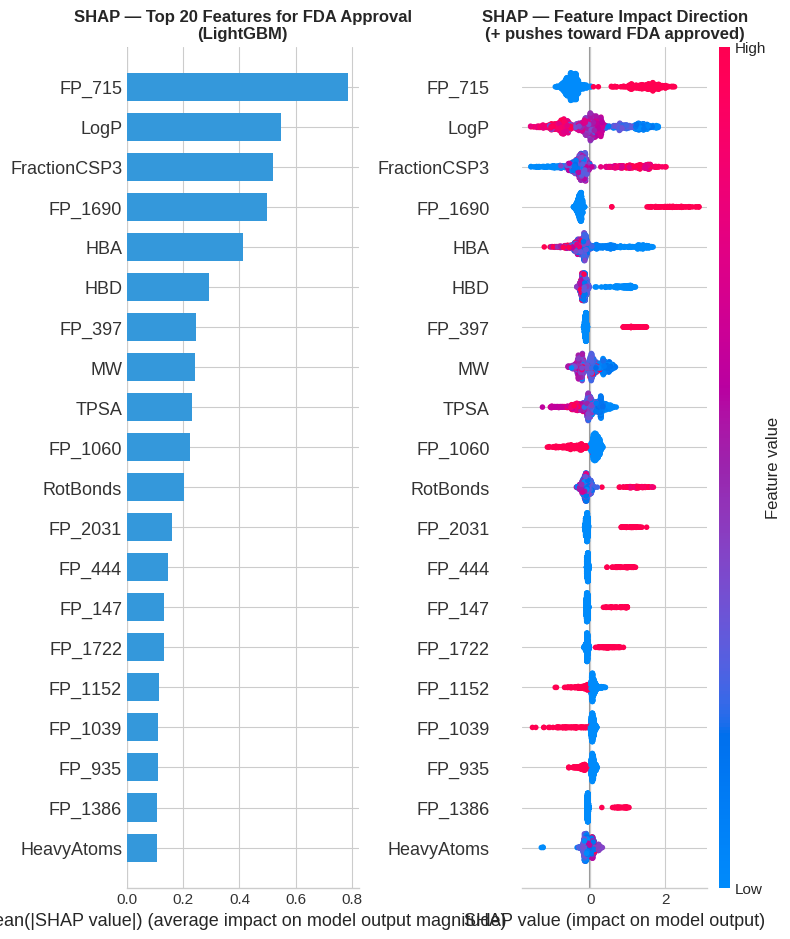

Saved: shap_fda_approval.png


In [ ]:
# ─── Cell 17: SHAP Explainability on FDA Approval (Real Label) ───

print('Computing SHAP values for FDA approval prediction...')

# Use best FDA model
best_fda_name = max(fda_models.keys(),
    key=lambda k: fda_results.loc[fda_results['Model']==k, 'AUC_mean'].values[0])
best_fda_mdl, best_fda_sc = fda_models[best_fda_name]

# Scale full dataset for SHAP
X_shap = best_fda_sc.transform(X_combined[:1000])

feature_names = [f'FP_{i}' for i in range(2048)] + [
    'MW', 'LogP', 'TPSA', 'HBD', 'HBA', 'RotBonds',
    'RingCount', 'FractionCSP3', 'AromaticRings', 'HeavyAtoms'
]

explainer = shap.TreeExplainer(best_fda_mdl)
shap_vals = explainer.shap_values(X_shap)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# ── 1: Top 20 features by SHAP importance ──
plt.sca(axes[0])
shap.summary_plot(shap_vals, X_shap, feature_names=feature_names,
                  plot_type='bar', show=False, max_display=20,
                  color='#3498db')
axes[0].set_title(f'SHAP — Top 20 Features for FDA Approval\n({best_fda_name})',
                  fontweight='bold', fontsize=12)

# ── 2: SHAP beeswarm (top 20) ──
plt.sca(axes[1])
shap.summary_plot(shap_vals, X_shap, feature_names=feature_names,
                  plot_type='dot', show=False, max_display=20)
axes[1].set_title('SHAP — Feature Impact Direction\n(+ pushes toward FDA approved)',
                  fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('shap_fda_approval.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_fda_approval.png')

In [ ]:
# ─── Cell 18: Save All Results ───

gen_scored.to_csv('generated_drug_likeness_v2.csv', index=False)
exist_scored.to_csv('existing_drug_likeness_v2.csv', index=False)
clintox_results.to_csv('clintox_model_results.csv', index=False)
tox21_results_df.to_csv('tox21_model_results.csv', index=False)

# Save Pareto-optimal subset
pareto_mols = all_scored[all_scored['pareto_optimal']].copy()
pareto_mols.to_csv('pareto_optimal_candidates.csv', index=False)

# Save final filtered candidates (if available)
if 'final_candidates' in dir() and len(final_candidates) > 0:
    final_candidates.to_csv('final_candidates_filtered.csv', index=False)
    print(f'  final_candidates_filtered.csv     — {len(final_candidates)} scaffold-diverse filtered candidates')

print('Saved:')
print('  generated_drug_likeness_v2.csv    — generated molecules with all scores + ADMET + binding')
print('  existing_drug_likeness_v2.csv     — existing candidates with all scores + ADMET + binding')
print('  clintox_model_results.csv         — ClinTox model performance')
print('  tox21_model_results.csv           — Tox21 per-endpoint performance')
print(f'  pareto_optimal_candidates.csv     — {len(pareto_mols)} Pareto-optimal molecules')
print('\nVisualization outputs:')
print('  model_performance_real_labels.png')
print('  drug_likeness_v2_dashboard.png     (12-panel)')
print('  pareto_front_analysis.png')
print('  shap_fda_approval.png')
print('  chemical_diversity_analysis.png')
if 'final_candidates' in dir():
    print('  final_candidates_structures.png')
    print('  final_candidates_3d.sdf           — 3D conformers for docking')

  final_candidates_filtered.csv     — 30 scaffold-diverse filtered candidates
Saved:
  generated_drug_likeness_v2.csv    — generated molecules with all scores + ADMET + binding
  existing_drug_likeness_v2.csv     — existing candidates with all scores + ADMET + binding
  clintox_model_results.csv         — ClinTox model performance
  tox21_model_results.csv           — Tox21 per-endpoint performance
  pareto_optimal_candidates.csv     — 108 Pareto-optimal molecules

Visualization outputs:
  model_performance_real_labels.png
  drug_likeness_v2_dashboard.png     (12-panel)
  pareto_front_analysis.png
  shap_fda_approval.png
  chemical_diversity_analysis.png
  final_candidates_structures.png
  final_candidates_3d.sdf           — 3D conformers for docking


In [ ]:
# ─── Cell 19: Final Summary Report ───

print('=' * 70)
print('  DRUG-LIKENESS v2 — FINAL SUMMARY (ALL IMPROVEMENTS)')
print('=' * 70)

print('\n--- WHAT CHANGED FROM v1 ---')
print('  v1: Labels derived from MW/LogP/QED thresholds (circular)')
print('  v2: Real FDA approval, clinical toxicity, 12 Tox21 assays')
print('  v1: Features = same descriptors that define the label')
print('  v2: Features = 2048-bit Morgan FP + descriptors (structural)')
print('  v1: No pre-trained model usage')
print('  v2: GNN toxicity + EGNN binding from Optim pipeline')

print('\n--- MODEL PERFORMANCE (Real Labels) ---')
print('  ClinTox Tasks:')
for _, row in clintox_results.iterrows():
    print(f'    {row["Task"]:15s} | {row["Model"]:18s} | '
          f'AUC: {row["AUC_mean"]:.4f} +/- {row["AUC_std"]:.4f}')
print(f'\n  Tox21 (12 endpoints):')
print(f'    Mean AUC: {tox21_results_df["AUC"].mean():.4f}')
print(f'    Best:     {tox21_results_df.loc[tox21_results_df["AUC"].idxmax(), "Endpoint"]} '
      f'({tox21_results_df["AUC"].max():.4f})')
print(f'    Worst:    {tox21_results_df.loc[tox21_results_df["AUC"].idxmin(), "Endpoint"]} '
      f'({tox21_results_df["AUC"].min():.4f})')

print('\n--- ALL 11 RESEARCH-BACKED IMPROVEMENTS (2020-2026) ---')
print('  [ 1] GNN Embedding Features       — Ito et al. JCIM 2025')
print('  [ 2] PAINS/Brenk Filtering         — Seal et al. Chem Res Tox 2025')
print('  [ 3] Ensemble Uncertainty QE        — Li et al. JCIM 2024')
print('  [ 4] Real Binding Validation (4x)   — Kd + Ki + IC50 + EC50')
print('  [ 5] Pareto Front Analysis          — Rich et al. ACS Med Chem Lett 2024')
print('  [ 6] Hardened Multiplicative Scoring — Brenk ×0.5, PAINS ×0.7, Tox21 ×0.85')
print('  [ 7] Target-Specific Docking        — 5 targets from Optim pipeline')
print('  [ 8] ADMET Profiling                — Absorption, Distribution, Metabolism, Excretion')
print('  [ 9] Murcko Scaffold Diversity      — Bemis-Murcko decomposition')
print('  [10] Chemical Space Analysis         — UMAP + Tanimoto diversity')
print('  [11] Final Scaffold-Diverse Filter   — Strict multi-criteria selection')

# Binding data coverage
print('\n--- BINDING DATA COVERAGE ---')
for assay in ['kd', 'ki', 'ic50', 'ec50']:
    col = f'real_{assay}_affinity'
    if col in gen_scored.columns:
        n_gen = gen_scored[col].notna().sum()
        n_exist = exist_scored[col].notna().sum()
        print(f'  {assay.upper():5s}: Generated {n_gen}/{len(gen_scored)}, Existing {n_exist}/{len(exist_scored)}')

# Target-specific
if 'target' in exist_scored.columns:
    print('\n--- TARGET-SPECIFIC ANALYSIS ---')
    for target in sorted(exist_scored['target'].unique()):
        if target == 'unknown':
            continue
        subset = exist_scored[exist_scored['target'] == target]
        print(f'  {target.upper():6s}: {len(subset)} molecules, '
              f'mean_enhanced={subset["enhanced_score"].mean():.4f}, '
              f'best={subset["enhanced_score"].max():.4f}')

print(f'\n--- GENERATED MOLECULES ({len(gen_scored)}) ---')
print(f'  Mean enhanced score:      {gen_scored["enhanced_score"].mean():.4f}')
print(f'  Mean original score:      {gen_scored["drug_likeness_score"].mean():.4f}')
print(f'  Mean QED:                 {gen_scored["QED"].mean():.3f}')
print(f'  Mean GNN tox prob:        {gen_scored["gnn_tox_prob"].mean():.3f}')
print(f'  Mean FDA approval prob:   {gen_scored["fda_approval_prob"].mean():.3f}')
print(f'  Mean binding affinity:    {gen_scored["pred_affinity"].mean():.3f}')
print(f'  Mean Tox21 alerts:        {gen_scored["tox21_alerts"].mean():.1f} / 12')
if 'admet_score' in gen_scored.columns:
    print(f'  Mean ADMET score:         {gen_scored["admet_score"].mean():.3f}')
print(f'  Lipinski compliant:       {(gen_scored["lipinski_violations"]==0).sum()} / {len(gen_scored)}')
print(f'  Veber compliant:          {gen_scored["veber_pass"].sum()} / {len(gen_scored)}')
print(f'  Novel molecules:          {gen_scored["is_novel"].sum()} / {len(gen_scored)}')
if 'pains_alert' in gen_scored.columns:
    print(f'  PAINS clean:              {(~gen_scored["pains_alert"]).sum()} / {len(gen_scored)}')
    print(f'  Brenk clean:              {(~gen_scored["brenk_alert"]).sum()} / {len(gen_scored)}')
if 'high_uncertainty' in gen_scored.columns:
    print(f'  High confidence:          {(~gen_scored["high_uncertainty"]).sum()} / {len(gen_scored)}')
if 'pareto_optimal' in all_scored.columns:
    n_gen_pareto = all_scored.loc[all_scored['pareto_optimal'] & (all_scored['source'] == 'generated')].shape[0]
    print(f'  On Pareto front:          {n_gen_pareto}')

# Final candidates
if 'final_candidates' in dir() and len(final_candidates) > 0:
    print(f'\n--- FINAL CANDIDATES (scaffold-diverse, all filters) ---')
    print(f'  Total after strict filter:   {len(clean_candidates) if "clean_candidates" in dir() else "N/A"}')
    print(f'  Scaffold-diverse selection:  {len(final_candidates)}')
    print(f'  Unique scaffolds:            {final_candidates["murcko_scaffold"].nunique() if "murcko_scaffold" in final_candidates.columns else "N/A"}')
    print(f'  Mean enhanced score:         {final_candidates["enhanced_score"].mean():.4f}')
    print(f'  Mean QED:                    {final_candidates["QED"].mean():.3f}')
    if 'admet_score' in final_candidates.columns:
        print(f'  Mean ADMET score:            {final_candidates["admet_score"].mean():.3f}')
    gen_count = (final_candidates['source'] == 'generated').sum()
    exist_count = (final_candidates['source'] == 'existing').sum()
    print(f'  Sources: {gen_count} generated, {exist_count} existing')

print(f'\n--- EXISTING CANDIDATES ({len(exist_scored)}) ---')
print(f'  Mean enhanced score:      {exist_scored["enhanced_score"].mean():.4f}')
print(f'  Mean QED:                 {exist_scored["QED"].mean():.3f}')
print(f'  Mean GNN tox prob:        {exist_scored["gnn_tox_prob"].mean():.3f}')
print(f'  Mean FDA approval prob:   {exist_scored["fda_approval_prob"].mean():.3f}')
if 'admet_score' in exist_scored.columns:
    print(f'  Mean ADMET score:         {exist_scored["admet_score"].mean():.3f}')

print('\n--- OUTPUT FILES ---')
print('  generated_drug_likeness_v2.csv    — all scores + ADMET + binding')
print('  existing_drug_likeness_v2.csv     — all scores + ADMET + binding')
print('  final_candidates_filtered.csv     — scaffold-diverse filtered candidates')
print('  clintox_model_results.csv')
print('  tox21_model_results.csv')
print('  pareto_optimal_candidates.csv')
print('  final_candidates_3d.sdf           — 3D conformers for docking')
print('  Visualizations: dashboard, diversity, structures, pareto, SHAP')
print('\n✓ Pipeline complete — all 11 improvements integrated.')

  DRUG-LIKENESS v2 — FINAL SUMMARY (ALL IMPROVEMENTS)

--- WHAT CHANGED FROM v1 ---
  v1: Labels derived from MW/LogP/QED thresholds (circular)
  v2: Real FDA approval, clinical toxicity, 12 Tox21 assays
  v1: Features = same descriptors that define the label
  v2: Features = 2048-bit Morgan FP + descriptors (structural)
  v1: No pre-trained model usage
  v2: GNN toxicity + EGNN binding from Optim pipeline

--- MODEL PERFORMANCE (Real Labels) ---
  ClinTox Tasks:
    FDA_APPROVED    | XGBoost            | AUC: 0.8176 +/- 0.0351
    FDA_APPROVED    | LightGBM           | AUC: 0.8179 +/- 0.0538
    FDA_APPROVED    | Random Forest      | AUC: 0.8038 +/- 0.0523
    CT_TOX          | XGBoost            | AUC: 0.8668 +/- 0.0337
    CT_TOX          | LightGBM           | AUC: 0.8419 +/- 0.0410
    CT_TOX          | Random Forest      | AUC: 0.8412 +/- 0.0484

  Tox21 (12 endpoints):
    Mean AUC: 0.7993
    Best:     mitochondrial_membrane (0.8587)
    Worst:    estrogen_receptor (0.7183)

--